# Variable Star Classification Using TESS Light Curves

**Comprehensive Analysis Notebook (v8)**

# Model Training Notebook

Input feature file:

```text
/data/projects/TESS-research/feature_extraction/TESS_features.parquet
```

This notebook trains and evaluates:

1. Logistic Regression baseline
2. Random Forest model
3. Feature importance analysis
4. Final held-out test evaluation


## Step 0 — Imports and Configuration

### Goal
Load required Python libraries and define global configuration values.

### Logic
- Use pandas/numpy for data handling.
- Use scikit-learn for splitting, preprocessing, modeling, and evaluation.
- Set the extracted feature parquet as the input.
- Define the target label column as `family`.

### Expected Result
The notebook environment is ready, and all later cells use the same paths and random seed.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

FeaturePath = Path("/data/projects/TESS-research/feature_extraction/TESS_features.parquet")
# FeaturePath = Path("/data/projects/TESS-research/feature_extraction/TESS_conditional_detrended_features.parquet")
OutputDir = Path("/data/projects/TESS-research/ml_analytics/output")
if not OutputDir.exists():
    OutputDir.mkdir(parents=True, exist_ok=True)

TargetColumn = "family"
StatusColumn = "FeatureStatus"
RandomState = 42


## Step 1 — Load Feature Table

### Goal
Load all extracted features from `TESS_features.parquet`.

### Logic
- Read the parquet file into a pandas DataFrame.
- Display the shape and the first few rows.

### Expected Result
You should see approximately one row per successfully processed target plus some rows with non-OK status, depending on the feature extraction output.


In [2]:
FeatureDf = pd.read_parquet(FeaturePath)

print(f"Loaded feature table: {FeatureDf.shape[0]} rows, {FeatureDf.shape[1]} columns")
display(FeatureDf.head())

# Data dictionary: data type and brief explanation for each column available in the feature table.
# This is intentionally generated from column names so the notebook stays useful
# even when the feature extractor adds or removes columns later.
def InferColumnRole(ColumnName):
    LowerName = ColumnName.lower()

    if ColumnName == TargetColumn:
        return "Target label"
    if ColumnName == StatusColumn or "status" in LowerName or "error" in LowerName:
        return "Feature extraction / QC metadata"
    if any(Token in LowerName for Token in ["name", "id", "tic", "vsx", "path", "source", "provenance", "quality"]):
        return "Object / provenance metadata"
    if pd.api.types.is_numeric_dtype(FeatureDf[ColumnName]) or pd.api.types.is_bool_dtype(FeatureDf[ColumnName]):
        return "Candidate model feature"
    return "Metadata / non-model column"

def InferColumnExplanation(ColumnName):
    LowerName = ColumnName.lower()

    ExactExplanations = {
        TargetColumn: "Variable-star family used as the supervised-learning target.",
        StatusColumn: "Feature-extraction status; rows marked ok are used for model training.",
        "FeatureError": "Error message captured when feature extraction failed or produced a warning.",
        "Name": "VSX object name.",
        "VSXId": "Identifier from the AAVSO VSX source catalog.",
        "VSXType": "Original VSX variability type before mapping into broader families.",
        "ticId": "TESS Input Catalog identifier associated with the object, when available.",
        "bestTicId": "Selected TIC match used for light-curve retrieval, when available.",
        "lightCurvePath": "Path to the light-curve file used for feature extraction.",
        "rawLightCurvePath": "Path to the raw light-curve file before standardization or processing.",
        "QualityLabel": "Pipeline quality label summarizing whether the light curve appears usable.",
        "Provenance": "Light-curve source such as SPOC, QLP, or TESSCut.",
    }
    if ColumnName in ExactExplanations:
        return ExactExplanations[ColumnName]

    PatternExplanations = [
        (["period"], "Period-related feature, usually derived from Lomb-Scargle or periodicity analysis."),
        (["freq", "frequency"], "Frequency-related feature corresponding to periodic variability search."),
        (["power"], "Periodogram power or relative strength of a periodic signal."),
        (["fap", "falsealarm"], "False-alarm probability or significance estimate for a periodogram peak."),
        (["amp", "amplitude"], "Brightness/flux variation amplitude measurement."),
        (["flux"], "Flux-distribution statistic computed from the light curve."),
        (["mag", "magnitude"], "Magnitude-related statistic, if magnitude values are present."),
        (["mean", "avg"], "Central-tendency statistic."),
        (["median"], "Robust central-tendency statistic."),
        (["std", "sigma"], "Scatter/noise or variability-width statistic."),
        (["var"], "Variance or variability-strength statistic."),
        (["skew"], "Asymmetry statistic of the flux distribution."),
        (["kurt"], "Tail/heavy-outlier statistic of the flux distribution."),
        (["min", "max", "range"], "Extreme-value or range statistic."),
        (["percentile", "quantile", "p05", "p10", "p25", "p75", "p90", "p95"], "Percentile/quantile statistic describing the light-curve distribution."),
        (["count", "num", "n_", "rows", "cadence"], "Count or cadence-coverage feature."),
        (["trend", "slope", "drift"], "Long-term trend or slope-related diagnostic."),
        (["quality", "mask", "finite", "nan"], "Light-curve quality, missingness, or valid-point diagnostic."),
        (["ra", "dec"], "Sky-coordinate metadata; useful for tracing objects but usually not a physical classifier feature."),
        (["sector"], "TESS sector coverage metadata."),
    ]

    for Keywords, Explanation in PatternExplanations:
        if any(Keyword in LowerName for Keyword in Keywords):
            return Explanation

    if pd.api.types.is_numeric_dtype(FeatureDf[ColumnName]) or pd.api.types.is_bool_dtype(FeatureDf[ColumnName]):
        return "Numeric/bool feature produced by the feature-extraction pipeline; inspect distribution and importance before interpretation."
    return "Metadata column used for tracing, filtering, or joining records rather than direct model training."

FeatureDictionaryDf = pd.DataFrame({
    "Column": FeatureDf.columns,
    "DataType": [str(FeatureDf[Col].dtype) for Col in FeatureDf.columns],
    "Role": [InferColumnRole(Col) for Col in FeatureDf.columns],
    "BriefExplanation": [InferColumnExplanation(Col) for Col in FeatureDf.columns],
})

print("Data dictionary: data type and brief explanation for each column")
display(FeatureDictionaryDf)


Loaded feature table: 7294 rows, 60 columns


,FeatureStatus,FeatureError,family,VSXType,VSXId,lightCurvePath,rawLightCurvePath,QualityLabel,QualityScore,Provenance,ProvenanceScore,OriginalFluxMedian,OriginalFluxStd,OriginalFluxSnr,LowSnr,LowQualityLightCurve,CadenceCount,TimeSpanDays,MedianCadenceDays,FluxStd,FluxMedian,FluxMad,FluxP05,FluxP10,FluxP90,FluxP95,FluxIqr,FluxAmplitude,FluxPercentAmplitude95To5,FluxPercentAmplitude90To10,FluxSkewness,FluxKurtosis,TailUpper,TailLower,TailAsymmetry,TailRatio,EtaVonNeumann,MaxAbsSlope,MedianAbsSuccessiveDiff,FractionBeyond1Std,FractionBeyond2Std,LsBestPeriod,LsMaxPower,LsFalseAlarmProbability,LsPeriod2,LsPeriod3,LsPower2,LsPower3,LsPeakPowerGap12,LsPeakPowerGap23,LsPowerRatio21,LsPowerRatio31,LsPeriodRatio21,LsPeriodRatio31,PhaseCurveStd,PhaseCurveRange,PhaseCurveSmoothness,PhasePeakPhase,PhaseTroughPhase,PhasePeakToTroughPhaseDelta
0,ok,NaN,CEPHEID,DCEPS,Gaia DR3 4685823446113073792,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,TESSCut,2.0,1.0,3.385947,0.295338,True,True,52596.0,2582.233205,0.002315,1.0,0.0,0.003505,-0.006333,-0.004953,0.183913,0.417345,0.014435,45.761783,0.423679,0.188865,23.101282,663.514392,0.417345,0.006333,0.411012,65.896105,0.032469,1252.881135,0.001209,0.014469,0.008480,13.496768,0.048319,0.000000e+00,13.503827,13.489718,0.046657,0.046515,0.001662,0.000142,0.965596,0.962654,1.000523,0.999478,0.108526,0.363780,0.089044,0.625510,0.974632,0.349122
1,ok,NaN,CEPHEID,CWB,ASASSN-V J001916.11-180430.8,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,TESSCut,2.0,1.0,19.096702,0.052365,True,True,12767.0,1119.891284,0.002315,1.0,0.0,0.001206,-0.002245,-0.001788,0.113524,0.296530,0.003519,20.529776,0.298775,0.115311,14.020774,218.303633,0.296530,0.002245,0.294285,132.074286,0.010559,365.507874,0.000134,0.013081,0.009478,14.212014,0.052479,4.048537e-144,14.394691,14.033917,0.052035,0.051907,0.000443,0.000128,0.991554,0.989106,1.012854,0.987469,0.160734,0.640752,0.156908,0.787201,0.077085,0.289884
2,ok,NaN,CEPHEID,CWB,CSS_J014935.9+141132,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,TESSCut,2.0,1.0,2.866330,0.348878,True,True,28154.0,812.271193,0.002315,1.0,0.0,0.008599,-0.017720,-0.014235,0.582287,1.870568,0.016360,24.453650,1.888289,0.596522,8.507117,118.917512,1.870568,0.017720,1.852848,105.560110,0.048921,2701.164441,0.000629,0.068303,0.040136,14.120878,0.074686,0.000000e+00,14.396174,13.855913,0.073810,0.073272,0.000876,0.000537,0.988269,0.981074,1.019496,0.981236,0.346630,1.472735,0.332614,0.026434,0.275024,0.248590
3,ok,NaN,CEPHEID,DCEP,Gaia DR3 461049865760507904,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,QLP,1.0,1.0,0.747987,1.336922,True,True,34615.0,1872.147960,0.002315,1.0,0.0,0.069352,-0.119138,-0.102901,0.113327,0.128391,0.138762,126.555590,0.247528,0.216227,104.972358,11775.637053,0.128391,0.119138,0.009253,1.077663,1.730303,51493.174857,0.012657,0.007107,0.001156,3.926308,0.003738,4.188952e-23,3.925485,3.927132,0.003654,0.003650,0.000084,0.000004,0.977464,0.976398,0.999790,1.000210,0.073633,0.217096,0.025917,0.775062,0.475095,0.299967
4,ok,NaN,CEPHEID,DCEPS,Gaia DR3 4662956971490538880,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,TESSCut,2.0,1.0,1.778965,0.562125,True,True,281759.0,2720.548082,0.002315,1.0,0.0,0.017102,-0.044715,-0.023942,0.652408,1.575629,0.094719,34.542061,1.620344,0.676350,7.198388,85.553137,1.575629,0.044715,1.530915,35.237350,0.023435,623.425288,0.002203,0.060609,0.035875,13.588779,0.032516,0.000000e+00,13.595570,13.581995,0.032217,0.029783,0.000300,0.002434,0.990783,0.915923,1.000500,0.999501,0.034486,0.119370,0.021449,0.675007,0.325098,0.349909


Data dictionary: data type and brief explanation for each column


,Column,DataType,Role,BriefExplanation
0,FeatureStatus,str,Feature extraction / QC metadata,Feature-extraction status; rows marked ok are ...
1,FeatureError,str,Feature extraction / QC metadata,Error message captured when feature extraction...
2,family,str,Target label,Variable-star family used as the supervised-le...
3,VSXType,str,Object / provenance metadata,Original VSX variability type before mapping i...
4,VSXId,str,Object / provenance metadata,Identifier from the AAVSO VSX source catalog.
5,lightCurvePath,str,Object / provenance metadata,Path to the light-curve file used for feature ...
6,rawLightCurvePath,str,Object / provenance metadata,Path to the raw light-curve file before standa...
7,QualityLabel,str,Object / provenance metadata,Pipeline quality label summarizing whether the...
8,QualityScore,float64,Object / provenance metadata,"Light-curve quality, missingness, or valid-poi..."
9,Provenance,str,Object / provenance metadata,"Light-curve source such as SPOC, QLP, or TESSCut."


## Step 2 — Check Feature Extraction Status

### Goal
Confirm which rows are usable for model training.

### Logic
- Count values in `FeatureStatus`.
- Keep only rows where `FeatureStatus == "ok"`.
- Drop rows with missing target label.

### Expected Result
Most rows should be `ok`. Rows with `missing_lightcurve_path` or failed extraction should be excluded from modeling.


In [3]:
if StatusColumn in FeatureDf.columns:
    display(FeatureDf[StatusColumn].value_counts(dropna=False))
    ModelDf = FeatureDf[FeatureDf[StatusColumn] == "ok"].copy()
else:
    print(f"Warning: {StatusColumn} not found; using all rows.")
    ModelDf = FeatureDf.copy()

ModelDf = ModelDf.dropna(subset=[TargetColumn]).copy()

print(f"Rows available for modeling: {len(ModelDf)}")
display(ModelDf[TargetColumn].value_counts())


FeatureStatus
ok                  7281
failed                11
too_few_cadences       2
Name: count, dtype: int64

Rows available for modeling: 7281


family
ELLIPSOIDAL_ROT    982
YSO                970
DSCT_SXPHE         968
CEPHEID            962
LONG_PERIOD        959
ECLIPSING          956
RRLYR              917
CV                 516
XRAY                51
Name: count, dtype: int64

## Step 3 — Select Feature Columns After Redundancy Reduction

The currently loaded FeatureExtractor parquet contains **60 columns total**. After excluding identification/status columns and the legacy redundant raw statistics listed below, this notebook selects **49 numeric candidate model features** before the Spearman near-duplicate filtering in Step 4.

The eight legacy redundant output features are:
`FluxVariance`, `FluxMean`, `FluxP25`, `FluxP75`, `FluxMin`, `FluxMax`, `FluxP01`, and `FluxP99`.

This notebook explicitly excludes those columns as a backward-compatibility safeguard when an older feature parquet is loaded. Temporary values may still be calculated inside the extractor to derive retained features such as `FluxIqr`, `FluxAmplitude`, `TailUpper`, and `TailLower`, but they are not used as separate model inputs.

Lomb–Scargle features, including `LsPeakPowerGap12` and `LsPeakPowerGap23`, are now produced directly by the FeatureExtractor; this analysis notebook does not create alias or transformed LS features.


### Official predictor-set policy

`ProvenanceScore` is explicitly excluded from the predictive feature set. Provenance is retained only as metadata and as the experimental grouping variable. This prevents the classifier from directly using provenance information when predicting variable-star class.

With `ProvenanceScore` removed, the modeling workflow begins with 48 numeric candidate predictors. The existing Spearman near-redundancy filter (absolute correlation > 0.95) removes 9 features, leaving 39 predictors for the Random Forest analyses.

The corrected rerun preserves the paper's main conclusion: provenance-associated performance differences remain in both unmatched and matched-star experiments, and the matched SPOC--TESSCut accuracy gap becomes larger rather than smaller.


In [4]:
# Redundant Feature Extractor outputs removed in the 2026-07-30 schema.
# Keep this explicit exclusion for backward compatibility with older parquet files.
RedundantFeatureColumns = {
    "FluxVariance",  # FluxStd ** 2
    "FluxMean",      # redundant with FluxMedian after standardization
    "FluxP25",       # retained only internally to derive FluxIqr
    "FluxP75",       # retained only internally to derive FluxIqr
    "FluxMin",       # retained only internally to derive FluxAmplitude
    "FluxMax",       # retained only internally to derive FluxAmplitude
    "FluxP01",       # highly correlated with FluxP05
    "FluxP99",       # highly correlated with FluxP95
}

ExcludeColumns = {
    TargetColumn,
    StatusColumn,
    "FeatureError",
    "Name",
    "VSXId",
    "VSXType",
    "ticId",
    "bestTicId",
    "lightCurvePath",
    "rawLightCurvePath",
    "QualityLabel",
    "Provenance",
    "ProvenanceScore",
    *RedundantFeatureColumns,
}

NumericColumns = ModelDf.select_dtypes(include=[np.number, bool]).columns.tolist()

FeatureColumns = [
    Col for Col in NumericColumns
    if Col not in ExcludeColumns
]

PresentRedundantFeatureColumns = sorted(
    RedundantFeatureColumns.intersection(ModelDf.columns)
)
MissingRedundantFeatureColumns = sorted(
    RedundantFeatureColumns.difference(ModelDf.columns)
)

print(f"Selected numeric model features before correlation filtering: {len(FeatureColumns)}")
if PresentRedundantFeatureColumns:
    print(
        "Excluded legacy redundant columns found in the loaded parquet: "
        + ", ".join(PresentRedundantFeatureColumns)
    )
else:
    print("Loaded feature parquet follows the current 60-column extractor schema.")


assert "ProvenanceScore" not in FeatureColumns, (
    "ProvenanceScore must remain metadata and must not enter the predictive feature set."
)
print("ProvenanceScore excluded from predictive model features.")
assert not RedundantFeatureColumns.intersection(FeatureColumns), (
    "Redundant extractor columns unexpectedly entered FeatureColumns."
)

FeatureDescriptionMap = {
    "QualityScore": "Numeric encoding of light-curve quality; lower-quality data may reduce classification reliability.",
    "OriginalFluxMedian": "Median flux before final standardization; captures baseline brightness scale from the extracted light curve.",
    "OriginalFluxStd": "Standard deviation of original flux; measures raw variability/noise amplitude before normalization.",
    "OriginalFluxSnr": "Signal-to-noise style summary from original flux; low values indicate noisier light curves.",
    "LowSnr": "Boolean/indicator flag showing whether the light curve has low signal-to-noise.",
    "LowQualityLightCurve": "Boolean/indicator flag showing whether quality checks marked the light curve as low quality.",
    "CadenceCount": "Number of valid time samples used for feature extraction.",
    "TimeSpanDays": "Total time coverage of the light curve in days.",
    "MedianCadenceDays": "Median spacing between consecutive observations in days.",
    "FluxStd": "Standard deviation of normalized flux; basic variability amplitude metric.",
    "FluxMedian": "Median normalized flux value; robust center of the flux distribution.",
    "FluxMad": "Median absolute deviation of flux; robust variability metric less sensitive to outliers.",
    "FluxP05": "5th percentile of normalized flux; robust lower-tail brightness value.",
    "FluxP10": "10th percentile of normalized flux; lower distribution summary.",
    "FluxP90": "90th percentile of normalized flux; upper distribution summary.",
    "FluxP95": "95th percentile of normalized flux; robust upper-tail brightness value.",
    "FluxIqr": "Interquartile range of flux, P75 - P25; robust variability spread.",
    "FluxAmplitude": "Peak-to-peak flux range, usually FluxMax - FluxMin.",
    "FluxPercentAmplitude95To5": "Robust amplitude based on P95 - P05; reduces sensitivity to extreme outliers.",
    "FluxPercentAmplitude90To10": "Robust amplitude based on P90 - P10; reduces sensitivity to extreme outliers.",
    "FluxSkewness": "Asymmetry of the flux distribution; useful for sharp dips or bursts.",
    "FluxKurtosis": "Tail heaviness/peakedness of the flux distribution; can indicate outliers or sharp events.",
    "TailUpper": "Upper-tail strength of the flux distribution.",
    "TailLower": "Lower-tail strength of the flux distribution.",
    "TailAsymmetry": "Difference between upper and lower tail behavior; useful for eclipse-like dips or flare-like brightenings.",
    "TailRatio": "Ratio of upper-tail to lower-tail behavior; another tail asymmetry measure.",
    "EtaVonNeumann": "Von Neumann eta statistic; measures point-to-point smoothness versus random scatter.",
    "MaxAbsSlope": "Maximum absolute slope between neighboring points; captures rapid changes.",
    "MedianAbsSuccessiveDiff": "Median absolute difference between successive flux points; robust short-timescale variability metric.",
    "FractionBeyond1Std": "Fraction of points more than 1 standard deviation from the mean.",
    "FractionBeyond2Std": "Fraction of points more than 2 standard deviations from the mean; outlier/extreme-variation metric.",
    "LsBestPeriod": "Best period from Lomb-Scargle periodogram.",
    "LsBestFrequency": "Frequency corresponding to the strongest Lomb-Scargle periodogram peak.",
    "LsMaxPower": "Maximum Lomb-Scargle power; strength of the dominant periodic signal.",
    "LsFalseAlarmProbability": "False-alarm probability for the strongest Lomb-Scargle peak; smaller values imply more significant periodicity.",
    "LsPeakPowerGap12": "Difference between the strongest and second-strongest sampled Lomb-Scargle powers (LsMaxPower - LsPower2); measures dominance of the primary sampled peak.",
    "LsPeakPowerGap23": "Difference between the second- and third-strongest sampled Lomb-Scargle powers (LsPower2 - LsPower3); measures separation among secondary sampled peaks.",
    "LsPeriod2": "Period corresponding to the second strongest Lomb-Scargle peak.",
    "LsPeriod3": "Period corresponding to the third strongest Lomb-Scargle peak.",
    "LsPower2": "Lomb-Scargle power of the second strongest peak.",
    "LsPower3": "Lomb-Scargle power of the third strongest peak.",
    "LsPowerRatio21": "Power ratio of second to first Lomb-Scargle peak; describes competing periodic signals or aliases.",
    "LsPowerRatio31": "Power ratio of third to first Lomb-Scargle peak; describes weaker competing periodic signals or aliases.",
    "LsPeriodRatio21": "Period ratio of second to first Lomb-Scargle peak; useful for harmonics and alias structure.",
    "LsPeriodRatio31": "Period ratio of third to first Lomb-Scargle peak; useful for harmonics and alias structure.",
    "PhaseCurveStd": "Standard deviation of the phase-folded light curve; variability after folding by best period.",
    "PhaseCurveRange": "Range of the phase-folded light curve; folded amplitude estimate.",
    "PhaseCurveSmoothness": "Smoothness metric of the phase-folded curve; helps separate smooth pulsators from sharper eclipsing shapes.",
    "PhasePeakPhase": "Phase location of the folded-curve maximum.",
    "PhaseTroughPhase": "Phase location of the folded-curve minimum.",
    "PhasePeakToTroughPhaseDelta": "Phase separation between peak and trough; captures folded light-curve shape symmetry.",
}

def describeFeature(FeatureName):
    if FeatureName in FeatureDescriptionMap:
        return FeatureDescriptionMap[FeatureName]
    if FeatureName.startswith("FluxP"):
        return "Flux percentile feature; summarizes the distribution of normalized flux values."
    if FeatureName.startswith("Flux"):
        return "Flux-distribution feature; summarizes variability, amplitude, or distribution shape."
    if FeatureName.startswith("Ls"):
        return "Lomb-Scargle periodogram feature; summarizes periodicity and period-search structure."
    if FeatureName.startswith("Phase"):
        return "Phase-folded light-curve feature; summarizes shape after folding by the best period."
    if FeatureName.lower().endswith("score"):
        return "Numeric score used by the model; check upstream feature extraction logic for exact definition."
    return "Selected numeric model input feature; add a more specific description if this feature becomes important."

FeatureInfoDf = pd.DataFrame({
    "FeatureColumn": FeatureColumns,
    "DataType": [str(ModelDf[Col].dtype) for Col in FeatureColumns],
    "Description": [describeFeature(Col) for Col in FeatureColumns],
})

print(f"Selected {len(FeatureColumns)} numeric feature columns.")
display(FeatureInfoDf)


Selected numeric model features before correlation filtering: 48
Loaded feature parquet follows the current 60-column extractor schema.
ProvenanceScore excluded from predictive model features.
Selected 48 numeric feature columns.


,FeatureColumn,DataType,Description
0,QualityScore,float64,Numeric encoding of light-curve quality; lower...
1,OriginalFluxMedian,float64,Median flux before final standardization; capt...
2,OriginalFluxStd,float64,Standard deviation of original flux; measures ...
3,OriginalFluxSnr,float64,Signal-to-noise style summary from original fl...
4,CadenceCount,float64,Number of valid time samples used for feature ...
5,TimeSpanDays,float64,Total time coverage of the light curve in days.
6,MedianCadenceDays,float64,Median spacing between consecutive observation...
7,FluxStd,float64,Standard deviation of normalized flux; basic v...
8,FluxMedian,float64,Median normalized flux value; robust center of...
9,FluxMad,float64,Median absolute deviation of flux; robust vari...


## Step 4 — Remove Near-Duplicate Correlated Features

### Goal
Conservatively reduce near-duplicate model inputs before training, making feature-importance results easier to interpret and less sensitive to which member of a highly correlated group is selected by the Random Forest.

### Logic
- Compute the absolute **Spearman rank correlation** between the numeric features selected in Step 3.
- Use a conservative threshold of `|ρ| > 0.95`.
- Process features in their existing Step 3 order and retain the first feature encountered from each near-duplicate group.
- Remove only later features that exceed the threshold with an already-retained feature.
- Update `FeatureColumns` and `FeatureInfoDf` so all later notebook steps use the reduced feature set.

Random Forest prediction does not require uncorrelated inputs. This filtering is intended primarily to reduce redundancy and improve the stability and interpretability of feature-importance analyses.

### Expected Result
A table lists every removed feature, the retained feature with which it was highly correlated, and their absolute Spearman correlation. With the conservative threshold, only near-duplicate features should be removed.


In [5]:
CorrelationThreshold = 0.95

# Spearman correlation is appropriate here because it detects strong monotonic
# relationships without assuming that the relationship is linear.
FeatureCorrelationDf = (
    ModelDf[FeatureColumns]
    .corr(method="spearman")
    .abs()
)

# Deterministic, conservative filtering:
# preserve the original Step 3 feature order and retain the first feature in
# each highly correlated group. A later feature is removed only when its
# absolute Spearman correlation with an already-retained feature exceeds the
# threshold.
RetainedFeatureColumns = []
RemovedCorrelatedFeatureRecords = []

for CandidateFeature in FeatureColumns:
    CorrelatedRetainedFeatures = []

    for RetainedFeature in RetainedFeatureColumns:
        CorrelationValue = FeatureCorrelationDf.loc[
            CandidateFeature,
            RetainedFeature,
        ]

        if pd.notna(CorrelationValue) and CorrelationValue > CorrelationThreshold:
            CorrelatedRetainedFeatures.append(
                (RetainedFeature, float(CorrelationValue))
            )

    if CorrelatedRetainedFeatures:
        KeptFeature, AbsoluteSpearmanCorrelation = max(
            CorrelatedRetainedFeatures,
            key=lambda Item: Item[1],
        )

        RemovedCorrelatedFeatureRecords.append({
            "RemovedFeature": CandidateFeature,
            "RetainedFeature": KeptFeature,
            "AbsoluteSpearmanCorrelation": AbsoluteSpearmanCorrelation,
        })
    else:
        RetainedFeatureColumns.append(CandidateFeature)

RemovedCorrelatedFeaturesDf = pd.DataFrame(
    RemovedCorrelatedFeatureRecords,
    columns=[
        "RemovedFeature",
        "RetainedFeature",
        "AbsoluteSpearmanCorrelation",
    ],
)

if not RemovedCorrelatedFeaturesDf.empty:
    RemovedCorrelatedFeaturesDf = RemovedCorrelatedFeaturesDf.sort_values(
        "AbsoluteSpearmanCorrelation",
        ascending=False,
    ).reset_index(drop=True)

OriginalFeatureCount = len(FeatureColumns)
FeatureColumns = RetainedFeatureColumns

# Keep the Step 3 feature dictionary synchronized with the reduced model inputs.
FeatureInfoDf = FeatureInfoDf[
    FeatureInfoDf["FeatureColumn"].isin(FeatureColumns)
].reset_index(drop=True)

print(f"Correlation threshold: |Spearman rho| > {CorrelationThreshold:.2f}")
print(f"Original feature count: {OriginalFeatureCount}")
print(f"Removed near-duplicate features: {len(RemovedCorrelatedFeaturesDf)}")
print(f"Retained feature count: {len(FeatureColumns)}")

if RemovedCorrelatedFeaturesDf.empty:
    print("No near-duplicate feature pairs exceeded the threshold.")
else:
    display(RemovedCorrelatedFeaturesDf)

print("Retained model features:")
display(FeatureInfoDf)


Correlation threshold: |Spearman rho| > 0.95
Original feature count: 48
Removed near-duplicate features: 9
Retained feature count: 39


,RemovedFeature,RetainedFeature,AbsoluteSpearmanCorrelation
0,TailLower,FluxP05,1.000000
1,TailUpper,FluxP95,1.000000
2,LsPower2,LsMaxPower,0.999891
3,LsPower3,LsMaxPower,0.999626
4,PhaseCurveRange,PhaseCurveStd,0.992349
5,FluxP10,FluxP05,0.971015
6,FluxPercentAmplitude90To10,FluxP90,0.968242
7,OriginalFluxSnr,OriginalFluxStd,0.964505
8,PhaseCurveSmoothness,PhaseCurveStd,0.953840


Retained model features:


,FeatureColumn,DataType,Description
0,QualityScore,float64,Numeric encoding of light-curve quality; lower...
1,OriginalFluxMedian,float64,Median flux before final standardization; capt...
2,OriginalFluxStd,float64,Standard deviation of original flux; measures ...
3,CadenceCount,float64,Number of valid time samples used for feature ...
4,TimeSpanDays,float64,Total time coverage of the light curve in days.
5,MedianCadenceDays,float64,Median spacing between consecutive observation...
6,FluxStd,float64,Standard deviation of normalized flux; basic v...
7,FluxMedian,float64,Median normalized flux value; robust center of...
8,FluxMad,float64,Median absolute deviation of flux; robust vari...
9,FluxP05,float64,5th percentile of normalized flux; robust lowe...


## Step 5 — Inspect Missing Values

### Goal
Understand which features contain missing values before modeling.

### Logic
- Compute missing-value rate for each selected feature.
- Sort features by missing rate.
- Later model pipelines will impute missing values using the training set only.

### Expected Result
Some missing values are normal, especially for period or phase features when a reliable period cannot be estimated.


In [6]:
MissingRate = ModelDf[FeatureColumns].isna().mean().sort_values(ascending=False)
display(MissingRate.head(40))


QualityScore                   0.0
OriginalFluxMedian             0.0
OriginalFluxStd                0.0
CadenceCount                   0.0
TimeSpanDays                   0.0
MedianCadenceDays              0.0
FluxStd                        0.0
FluxMedian                     0.0
FluxMad                        0.0
FluxP05                        0.0
FluxP90                        0.0
FluxP95                        0.0
FluxIqr                        0.0
FluxAmplitude                  0.0
FluxPercentAmplitude95To5      0.0
FluxSkewness                   0.0
FluxKurtosis                   0.0
TailAsymmetry                  0.0
TailRatio                      0.0
EtaVonNeumann                  0.0
MaxAbsSlope                    0.0
MedianAbsSuccessiveDiff        0.0
FractionBeyond1Std             0.0
FractionBeyond2Std             0.0
LsBestPeriod                   0.0
LsMaxPower                     0.0
LsFalseAlarmProbability        0.0
LsPeriod2                      0.0
LsPeriod3           

## Step 6 — Persistent Train / Validation / Test Split

### Goal
Separate data into training, validation, and test sets in a reproducible way that does **not** reshuffle samples every time the notebook is run.

### Logic
- Store the split input files under `OutputDir`:
  - `train_input.parquet`
  - `validation_input.parquet`
  - `test_input.parquet`
- If the saved split files already exist, load them and reuse the exact same rows.
- After loading, run a feature schema check against the current `FeatureColumns` list.
- If files are missing or the saved files are stale/incompatible with the current feature schema, regenerate and save a new stratified 70% / 15% / 15% split.
- This avoids accidentally moving validation/test samples into training during normal reruns, while also avoiding silent bugs after feature-engineering changes.

### Expected Result
The class distribution should be similar across train, validation, and test sets, and the split should remain stable across notebook runs.

In [7]:
TrainInputPath = OutputDir / "train_input.parquet"
ValInputPath = OutputDir / "validation_input.parquet"
TestInputPath = OutputDir / "test_input.parquet"

SplitPaths = {
    "train": TrainInputPath,
    "validation": ValInputPath,
    "test": TestInputPath,
}

RequiredColumns = set(FeatureColumns + [TargetColumn])


def getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf):
    """Return missing model columns after all derived features have been added."""
    MissingBySplit = {}
    for SplitName, SplitDf in [("train", TrainDf), ("validation", ValDf), ("test", TestDf)]:
        MissingColumns = sorted(RequiredColumns - set(SplitDf.columns))
        if MissingColumns:
            MissingBySplit[SplitName] = MissingColumns
    return MissingBySplit


def createAndSavePersistentSplits():
    """Create a fresh stratified split from ModelDf and save it to parquet files."""
    TrainDf, TempDf = train_test_split(
        ModelDf,
        test_size=0.30,
        stratify=ModelDf[TargetColumn],
        random_state=RandomState,
    )

    ValDf, TestDf = train_test_split(
        TempDf,
        test_size=0.50,
        stratify=TempDf[TargetColumn],
        random_state=RandomState,
    )


    TrainDf.to_parquet(TrainInputPath, index=False)
    ValDf.to_parquet(ValInputPath, index=False)
    TestDf.to_parquet(TestInputPath, index=False)

    return TrainDf, ValDf, TestDf


# Research-grade persistent split rule:
# - Reuse existing split files when their schema still matches the current feature set.
# - Regenerate the split files automatically when files are missing or stale.
# - A stale split usually means the notebook added/renamed features after the old parquet files were created.
# This avoids silent bugs where the model trains on an old feature schema.
NeedRegenerateSplits = False
RegenerationReason = None

if TestInputPath.exists():
    MissingSplitFiles = [PathObj for PathObj in SplitPaths.values() if not PathObj.exists()]
    if MissingSplitFiles:
        NeedRegenerateSplits = True
        RegenerationReason = (
            "test split exists, but one or more split files are missing: "
            + ", ".join(str(PathObj) for PathObj in MissingSplitFiles)
        )
    else:
        TrainDf = pd.read_parquet(TrainInputPath)
        ValDf = pd.read_parquet(ValInputPath)
        TestDf = pd.read_parquet(TestInputPath)

        MissingBySplit = getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf)

        if MissingBySplit:
            NeedRegenerateSplits = True
            RegenerationReason = "existing split files have a stale feature schema: " + str(MissingBySplit)
        else:
            print("Loaded existing persistent train/validation/test split files.")
            print("Feature schema check passed; existing split files are compatible with the current notebook.")
else:
    NeedRegenerateSplits = True
    RegenerationReason = "persistent split files do not exist yet"

if NeedRegenerateSplits:
    print("Regenerating persistent train/validation/test split files because:")
    print(RegenerationReason)
    TrainDf, ValDf, TestDf = createAndSavePersistentSplits()

    MissingBySplit = getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf)
    if MissingBySplit:
        raise ValueError("Newly generated split files are still missing required columns: " + str(MissingBySplit))

    print("Created and saved compatible persistent train/validation/test split files.")

XTrain = TrainDf[FeatureColumns]
yTrain = TrainDf[TargetColumn]

XVal = ValDf[FeatureColumns]
yVal = ValDf[TargetColumn]

XTest = TestDf[FeatureColumns]
yTest = TestDf[TargetColumn]

print("Train:", XTrain.shape)
print("Validation:", XVal.shape)
print("Test:", XTest.shape)
print()
print("Split files:")
for PathToShow in [TrainInputPath, ValInputPath, TestInputPath]:
    print(PathToShow)

display(pd.DataFrame({
    "Train": yTrain.value_counts(),
    "Validation": yVal.value_counts(),
    "Test": yTest.value_counts(),
}).fillna(0).astype(int))


Regenerating persistent train/validation/test split files because:
persistent split files do not exist yet
Created and saved compatible persistent train/validation/test split files.
Train: (5096, 39)
Validation: (1092, 39)
Test: (1093, 39)

Split files:
/data/projects/TESS-research/ml_analytics/output/train_input.parquet
/data/projects/TESS-research/ml_analytics/output/validation_input.parquet
/data/projects/TESS-research/ml_analytics/output/test_input.parquet


,Train,Validation,Test
family,,,
CEPHEID,673,144,145
CV,361,78,77
DSCT_SXPHE,678,145,145
ECLIPSING,669,143,144
ELLIPSOIDAL_ROT,687,147,148
LONG_PERIOD,671,144,144
RRLYR,642,138,137
XRAY,36,8,7
YSO,679,145,146


## Step 7 — Train Logistic Regression Baseline

### Goal
Train a simple baseline classifier.

### Logic
- Impute missing values using median values from training data.
- Standardize features because Logistic Regression is scale-sensitive.
- Use class balancing because family counts may not be equal.
- Evaluate on validation set.

### Expected Result
This gives a baseline validation accuracy and balanced accuracy. It also provides per-family precision, recall, and F1 scores.


In [8]:
LogisticModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RandomState,
        )),
    ]
)

LogisticModel.fit(XTrain, yTrain)
LogisticValPred = LogisticModel.predict(XVal)

LogisticValAccuracy = accuracy_score(yVal, LogisticValPred)
LogisticValBalancedAccuracy = balanced_accuracy_score(yVal, LogisticValPred)

print("Logistic Regression Validation Accuracy:", LogisticValAccuracy)
print("Logistic Regression Validation Balanced Accuracy:", LogisticValBalancedAccuracy)
print()
print(classification_report(yVal, LogisticValPred))


Logistic Regression Validation Accuracy: 0.27014652014652013
Logistic Regression Validation Balanced Accuracy: 0.3212012395242209

                 precision    recall  f1-score   support

        CEPHEID       0.36      0.23      0.28       144
             CV       0.23      0.28      0.25        78
     DSCT_SXPHE       0.25      0.06      0.10       145
      ECLIPSING       0.19      0.14      0.16       143
ELLIPSOIDAL_ROT       0.23      0.18      0.20       147
    LONG_PERIOD       0.45      0.44      0.45       144
          RRLYR       0.22      0.28      0.24       138
           XRAY       0.04      0.75      0.08         8
            YSO       0.41      0.54      0.47       145

       accuracy                           0.27      1092
      macro avg       0.26      0.32      0.25      1092
   weighted avg       0.29      0.27      0.27      1092



## Step 8 — Train Random Forest Model

### Goal
Train a nonlinear model that can capture feature interactions.

### Logic
- Impute missing values using median values from training data.
- Do not standardize, because tree-based models do not require scaling.
- Use many trees for stable estimates.
- Use class-balanced subsampling to reduce class imbalance effects.
- Evaluate on validation set.

### Expected Result
Random Forest should ideally improve over Logistic Regression, especially if nonlinear relationships exist among period, amplitude, morphology, and variability features.


In [9]:
RandomForestModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RandomState,
        )),
    ]
)

RandomForestModel.fit(XTrain, yTrain)
RandomForestValPred = RandomForestModel.predict(XVal)

RandomForestValAccuracy = accuracy_score(yVal, RandomForestValPred)
RandomForestValBalancedAccuracy = balanced_accuracy_score(yVal, RandomForestValPred)

print("Random Forest Validation Accuracy:", RandomForestValAccuracy)
print("Random Forest Validation Balanced Accuracy:", RandomForestValBalancedAccuracy)
print()
print(classification_report(yVal, RandomForestValPred))


Random Forest Validation Accuracy: 0.40934065934065933
Random Forest Validation Balanced Accuracy: 0.3979111708952146

                 precision    recall  f1-score   support

        CEPHEID       0.46      0.50      0.48       144
             CV       0.54      0.27      0.36        78
     DSCT_SXPHE       0.36      0.26      0.30       145
      ECLIPSING       0.26      0.27      0.27       143
ELLIPSOIDAL_ROT       0.32      0.35      0.33       147
    LONG_PERIOD       0.59      0.65      0.62       144
          RRLYR       0.21      0.27      0.24       138
           XRAY       0.75      0.38      0.50         8
            YSO       0.68      0.63      0.66       145

       accuracy                           0.41      1092
      macro avg       0.46      0.40      0.42      1092
   weighted avg       0.42      0.41      0.41      1092



## Step 9 — Compare Validation Performance

### Goal
Compare the simple baseline and Random Forest on the same validation set.

### Logic
- Put validation accuracy and balanced accuracy into a compact table.
- Use balanced accuracy as an important metric because family counts may differ.

### Expected Result
If Random Forest is meaningfully better, it supports using a nonlinear model for the next phase.


In [10]:
ComparisonDf = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "ValidationAccuracy": LogisticValAccuracy,
            "ValidationBalancedAccuracy": LogisticValBalancedAccuracy,
        },
        {
            "Model": "Random Forest",
            "ValidationAccuracy": RandomForestValAccuracy,
            "ValidationBalancedAccuracy": RandomForestValBalancedAccuracy,
        },
    ]
)

display(ComparisonDf)


,Model,ValidationAccuracy,ValidationBalancedAccuracy
0,Logistic Regression,0.270147,0.321201
1,Random Forest,0.409341,0.397911


## Step 10 — Confusion Matrix

### Goal
Identify which star families are confused by the Random Forest model.

### Logic
- Compute confusion matrix on the validation set.
- Rows represent true labels.
- Columns represent predicted labels.
- Display both table and heatmap.

### Expected Result
This should reveal difficult class pairs, such as families with similar periods, amplitudes, or morphology.


,CEPHEID,CV,DSCT_SXPHE,ECLIPSING,ELLIPSOIDAL_ROT,LONG_PERIOD,RRLYR,XRAY,YSO
CEPHEID,72,2,8,8,11,14,20,0,9
CV,11,21,12,8,10,2,13,0,1
DSCT_SXPHE,13,2,38,31,16,9,30,0,6
ECLIPSING,7,3,13,39,35,6,36,0,4
ELLIPSOIDAL_ROT,13,6,14,25,52,12,17,0,8
LONG_PERIOD,13,1,3,5,13,93,9,0,7
RRLYR,18,3,18,27,23,6,37,0,6
XRAY,1,0,0,0,0,1,1,3,2
YSO,9,1,1,8,5,15,13,1,92


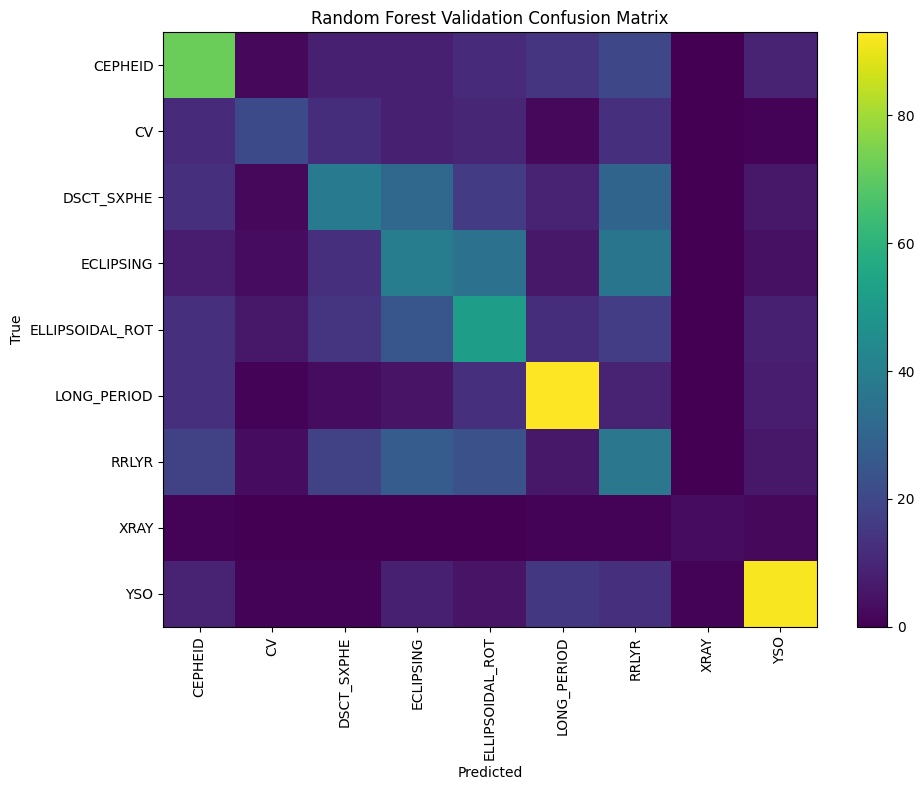

In [11]:
Labels = sorted(yVal.unique())

ConfMat = confusion_matrix(yVal, RandomForestValPred, labels=Labels)
ConfMatDf = pd.DataFrame(ConfMat, index=Labels, columns=Labels)

display(ConfMatDf)

plt.figure(figsize=(10, 8))
plt.imshow(ConfMat, aspect="auto")
plt.xticks(range(len(Labels)), Labels, rotation=90)
plt.yticks(range(len(Labels)), Labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Validation Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 11 — Feature Importance

### Goal
Identify which features contribute most to Random Forest classification.

### Logic
- Extract feature importance from the trained Random Forest.
- Rank features from most to least important.
- Plot top features.

### Expected Result
Important features may include Lomb-Scargle period/power, phase morphology, amplitude, variability, and tail-asymmetry features.


,Feature,Importance
19,EtaVonNeumann,0.046418
2,OriginalFluxStd,0.041453
28,LsPeriod3,0.039066
21,MedianAbsSuccessiveDiff,0.038152
20,MaxAbsSlope,0.037089
24,LsBestPeriod,0.036166
27,LsPeriod2,0.034597
3,CadenceCount,0.033368
18,TailRatio,0.033097
25,LsMaxPower,0.032032


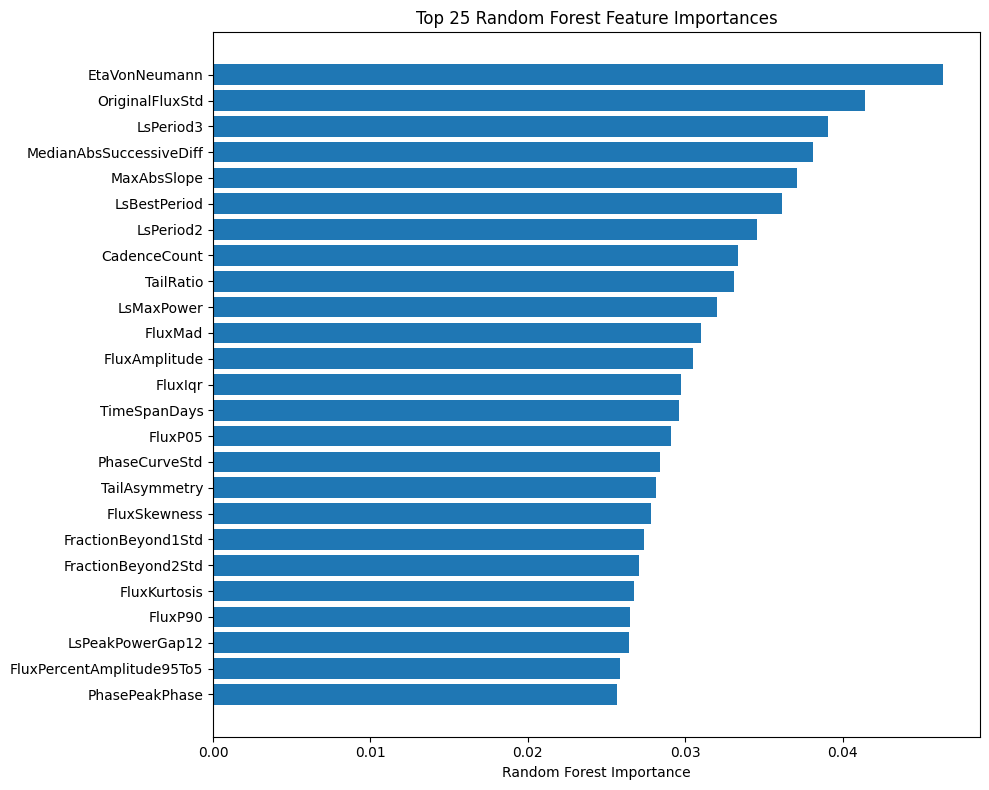

In [12]:
RfClassifier = RandomForestModel.named_steps["model"]

ImportanceDf = pd.DataFrame({
    "Feature": FeatureColumns,
    "Importance": RfClassifier.feature_importances_,
}).sort_values("Importance", ascending=False)

display(ImportanceDf.head(30))

TopN = 25
TopImportance = ImportanceDf.head(TopN).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(TopImportance["Feature"], TopImportance["Importance"])
plt.xlabel("Random Forest Importance")
plt.title(f"Top {TopN} Random Forest Feature Importances")
plt.tight_layout()
plt.show()


## Step 12 — Permutation Importance

### Goal

Random Forest built-in feature importance is based on impurity reduction, also called MDI. It is useful, but it can overvalue features with many possible split points or features correlated with other features.

Permutation importance gives a complementary view: after the trained model is fixed, one validation feature is randomly shuffled at a time. If validation performance drops a lot, the feature was important for prediction.

### Expected result

Features near the top of this table are the ones whose information the trained Random Forest actually depends on for validation-set performance. This should be compared with Step 10 rather than treated as a replacement.


,Feature,PermutationImportanceMean,PermutationImportanceStd
0,MedianCadenceDays,0.043494,0.000630
1,MedianAbsSuccessiveDiff,0.040936,0.004441
2,OriginalFluxStd,0.038675,0.008236
3,FluxPercentAmplitude95To5,0.037260,0.001717
4,CadenceCount,0.035171,0.007338
5,LsPeriod3,0.033231,0.002435
6,MaxAbsSlope,0.032525,0.006313
7,FluxKurtosis,0.031592,0.006171
8,FluxP90,0.028714,0.006016
9,LsBestPeriod,0.026381,0.007510


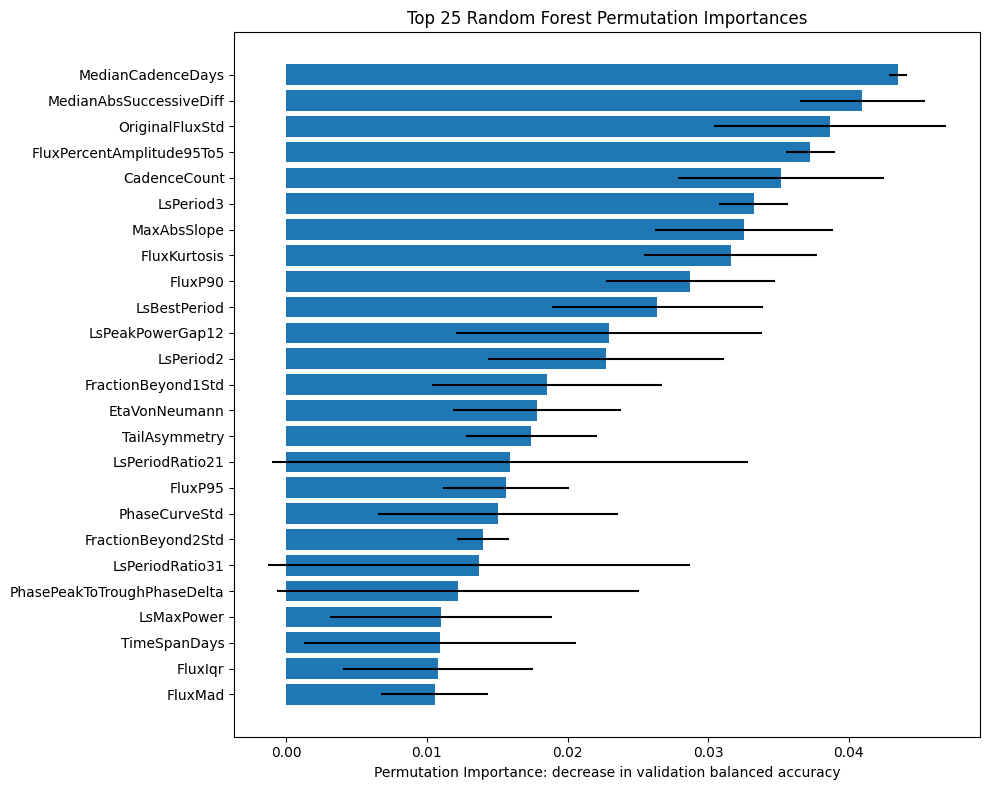

6100

In [13]:
from sklearn.inspection import permutation_importance
import gc

# Remove any large stale permutation result from an earlier run.
for VariableName in [
    "PermutationResult",
    "PermutationImportanceDf",
    "TopPermutationImportance",
]:
    if VariableName in globals():
        del globals()[VariableName]

gc.collect()

# n_jobs=1 avoids duplicating XVal and model data across worker processes.
# Five repeats are normally enough for this diagnostic analysis.
PermutationResult = permutation_importance(
    RandomForestModel,
    XVal,
    yVal,
    n_repeats=5,
    random_state=RandomState,
    scoring="balanced_accuracy",
    n_jobs=2,
)

# Copy only the compact summary arrays that are needed later.
PermutationImportanceDf = pd.DataFrame({
    "Feature": FeatureColumns,
    "PermutationImportanceMean":
        PermutationResult.importances_mean.copy(),
    "PermutationImportanceStd":
        PermutationResult.importances_std.copy(),
}).sort_values(
    "PermutationImportanceMean",
    ascending=False,
).reset_index(drop=True)

# The full result also contains an
# n_features × n_repeats importance matrix.
# It is no longer needed after extracting mean and standard deviation.
del PermutationResult
gc.collect()

display(PermutationImportanceDf.head(30))

TopN = 25
TopPermutationImportance = (
    PermutationImportanceDf
    .head(TopN)
    .iloc[::-1]
    .copy()
)

plt.figure(figsize=(10, 8))
plt.barh(
    TopPermutationImportance["Feature"],
    TopPermutationImportance["PermutationImportanceMean"],
    xerr=TopPermutationImportance["PermutationImportanceStd"],
)
plt.xlabel(
    "Permutation Importance: decrease in validation balanced accuracy"
)
plt.title(f"Top {TopN} Random Forest Permutation Importances")
plt.tight_layout()
plt.show()
plt.close()

del TopPermutationImportance
gc.collect()

## Step 13 — Final Test Evaluation

### Goal
Evaluate the selected Random Forest model on the held-out test set.

### Logic
- Use the trained Random Forest pipeline.
- Predict labels for the test set.
- Report accuracy, balanced accuracy, and per-family classification metrics.

### Expected Result
This gives the final held-out performance estimate. Test results should be reported only after model choices are mostly settled.


In [14]:
RandomForestTestPred = RandomForestModel.predict(XTest)

RandomForestTestAccuracy = accuracy_score(yTest, RandomForestTestPred)
RandomForestTestBalancedAccuracy = balanced_accuracy_score(yTest, RandomForestTestPred)

print("Random Forest Test Accuracy:", RandomForestTestAccuracy)
print("Random Forest Test Balanced Accuracy:", RandomForestTestBalancedAccuracy)
print()
print(classification_report(yTest, RandomForestTestPred))


Random Forest Test Accuracy: 0.39158279963403475
Random Forest Test Balanced Accuracy: 0.34030757854177235

                 precision    recall  f1-score   support

        CEPHEID       0.47      0.52      0.50       145
             CV       0.46      0.22      0.30        77
     DSCT_SXPHE       0.31      0.24      0.27       145
      ECLIPSING       0.20      0.23      0.22       144
ELLIPSOIDAL_ROT       0.30      0.31      0.30       148
    LONG_PERIOD       0.67      0.65      0.66       144
          RRLYR       0.16      0.23      0.19       137
           XRAY       0.00      0.00      0.00         7
            YSO       0.72      0.66      0.69       146

       accuracy                           0.39      1093
      macro avg       0.37      0.34      0.35      1093
   weighted avg       0.41      0.39      0.40      1093



/home/jamesliang/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jamesliang/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jamesliang/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

## Step 14 — Error Analysis: Correct vs Incorrect and Accuracy by Data Source

This section uses row-level predictions to diagnose *why* the model is making mistakes, not just how often it is wrong.

Two quick, high-value checks are included:

1. Compare correctly classified vs incorrectly classified samples using key period/amplitude/power features.
2. Compare accuracy by data provenance/source, such as SPOC, QLP, and TESSCut when the provenance column is available.

In [15]:
def firstExistingColumn(Df, CandidateColumns):
    for Col in CandidateColumns:
        if Col in Df.columns:
            return Col
    return None


def buildErrorAnalysisDf(SourceDf, X, y, SplitName):
    Df = SourceDf.copy()
    Df["split"] = SplitName
    Df["label"] = y.values
    Df["prediction"] = RandomForestModel.predict(X)
    Df["correct"] = Df["prediction"] == Df["label"]
    return Df


TrainErrorDf = buildErrorAnalysisDf(TrainDf, XTrain, yTrain, "train")
ValErrorDf = buildErrorAnalysisDf(ValDf, XVal, yVal, "validation")
TestErrorDf = buildErrorAnalysisDf(TestDf, XTest, yTest, "test")

ErrorAnalysisDf = pd.concat(
    [TrainErrorDf, ValErrorDf, TestErrorDf],
    ignore_index=True,
)

print("Random Forest accuracy by split:")
display(
    ErrorAnalysisDf
    .groupby("split")["correct"]
    .agg(accuracy="mean", sample_count="size")
    .reset_index()
)

# Pick the most useful available columns for the quick correct-vs-incorrect comparison.
BestPeriodColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "BestPeriod",
        "LombScargleBestPeriod",
        "LsBestPeriod",
        "Period",
        "period",
        "best_period",
        "Period1",
        "LsPeak1Period",
    ],
)

AmplitudeColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "FluxAmplitude",
        "FluxPercentAmplitude95To5",
        "FluxPercentAmplitude90To10",
        "Amplitude",
        "amplitude",
    ],
)

PowerColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "BestPower",
        "LombScargleBestPower",
        "LsBestPower",
        "LsPeak1Power",
        "Power1",
        "power",
    ],
)

DiagnosticColumns = [
    Col for Col in [BestPeriodColumn, AmplitudeColumn, PowerColumn]
    if Col is not None and Col in ErrorAnalysisDf.columns
]

print("Columns used for correct-vs-incorrect comparison:", DiagnosticColumns)

if DiagnosticColumns:
    CorrectVsIncorrectDf = (
        ErrorAnalysisDf
        .groupby("correct")[DiagnosticColumns]
        .agg(["mean", "median", "std", "count"])
    )
    display(CorrectVsIncorrectDf)
else:
    print("No matching period/amplitude/power diagnostic columns were found.")

# Accuracy by data source/provenance. This is important because SPOC, QLP, and TESSCut can have different noise and preprocessing behavior.
ProvenanceColumn = firstExistingColumn(
    ErrorAnalysisDf,
    ["Provenance", "provenance", "Source", "source", "LightCurveSource", "DataSource"],
)

if ProvenanceColumn is not None:
    print(f"Accuracy by data source using column: {ProvenanceColumn}")
    AccuracyBySourceDf = (
        ErrorAnalysisDf
        .groupby(["split", ProvenanceColumn])["correct"]
        .agg(accuracy="mean", sample_count="size")
        .reset_index()
        .sort_values(["split", "accuracy"], ascending=[True, False])
    )
    display(AccuracyBySourceDf)
else:
    print("No provenance/source column found. Accuracy-by-source analysis was skipped.")

# Top validation/test confusion pairs are often easier to interpret than the full confusion matrix.
TopConfusionPairsDf = (
    ErrorAnalysisDf
    .query("split in ['validation', 'test'] and correct == False")
    .groupby(["label", "prediction"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)

print("Top validation/test confusion pairs:")
display(TopConfusionPairsDf)


Random Forest accuracy by split:


,split,accuracy,sample_count
0,test,0.391583,1093
1,train,1.000000,5096
2,validation,0.409341,1092


Columns used for correct-vs-incorrect comparison: ['LsBestPeriod', 'FluxAmplitude']


LsBestPeriod                             FluxAmplitude                            
                mean     median        std count          mean     median        std count
correct                                                                                   
False      17.465486  14.386566  15.311263  1310     31.408441  23.716786  28.038533  1310
True       16.610961  14.347948  15.929200  5971     30.314143  21.735608  29.550684  5971

Accuracy by data source using column: Provenance


,split,Provenance,accuracy,sample_count
1,test,SPOC,0.791667,72
0,test,QLP,0.700535,187
2,test,TESSCut,0.287770,834
3,train,QLP,1.000000,988
4,train,SPOC,1.000000,353
5,train,TESSCut,1.000000,3755
7,validation,SPOC,0.797619,84
6,validation,QLP,0.668539,178
8,validation,TESSCut,0.314458,830


Top validation/test confusion pairs:


,label,prediction,count
26,ECLIPSING,RRLYR,72
19,DSCT_SXPHE,RRLYR,67
24,ECLIPSING,ELLIPSOIDAL_ROT,61
16,DSCT_SXPHE,ECLIPSING,60
31,ELLIPSOIDAL_ROT,ECLIPSING,57
45,RRLYR,ECLIPSING,55
33,ELLIPSOIDAL_ROT,RRLYR,48
5,CEPHEID,RRLYR,47
44,RRLYR,DSCT_SXPHE,45
46,RRLYR,ELLIPSOIDAL_ROT,44


## Step 15 — Save Useful Outputs

### Goal
Save key outputs for later reporting and paper-writing.

### Logic
- Save model comparison table.
- Save feature importance table.
- Save validation confusion matrix.

### Expected Result
CSV files are created next to the input feature file.


In [16]:
# Save summary artifacts
ComparisonPath = OutputDir / "model_comparison_validation.csv"
ImportancePath = OutputDir / "random_forest_feature_importance.csv"
PermutationImportancePath = OutputDir / "random_forest_permutation_importance.csv"
ConfusionPath = OutputDir / "random_forest_validation_confusion_matrix.csv"
ErrorAnalysisPath = OutputDir / "random_forest_error_analysis.parquet"
AccuracyBySourcePath = OutputDir / "random_forest_accuracy_by_source.csv"
TopConfusionPairsPath = OutputDir / "random_forest_top_confusion_pairs.csv"

ComparisonDf.to_csv(ComparisonPath, index=False)
ImportanceDf.to_csv(ImportancePath, index=False)
if "PermutationImportanceDf" in globals():
    PermutationImportanceDf.to_csv(PermutationImportancePath, index=False)
ConfMatDf.to_csv(ConfusionPath)
if "ErrorAnalysisDf" in globals():
    ErrorAnalysisDf.to_parquet(ErrorAnalysisPath, index=False)
if "AccuracyBySourceDf" in globals():
    AccuracyBySourceDf.to_csv(AccuracyBySourcePath, index=False)
if "TopConfusionPairsDf" in globals():
    TopConfusionPairsDf.to_csv(TopConfusionPairsPath, index=False)

# Save row-level train / validation / test predictions.
# These files keep the original metadata/features and append prediction columns,
# which makes later error analysis much easier.
def BuildPredictionOutputDf(SourceDf, X, y, SplitName):
    OutputDf = SourceDf.copy()

    LogisticPred = LogisticModel.predict(X)
    RandomForestPred = RandomForestModel.predict(X)

    OutputDf["Split"] = SplitName
    OutputDf["ActualFamily"] = y.values
    OutputDf["LogisticRegressionPrediction"] = LogisticPred
    OutputDf["RandomForestPrediction"] = RandomForestPred
    OutputDf["LogisticRegressionCorrect"] = OutputDf["ActualFamily"] == OutputDf["LogisticRegressionPrediction"]
    OutputDf["RandomForestCorrect"] = OutputDf["ActualFamily"] == OutputDf["RandomForestPrediction"]

    return OutputDf

TrainPredictionDf = BuildPredictionOutputDf(TrainDf, XTrain, yTrain, "train")
ValPredictionDf = BuildPredictionOutputDf(ValDf, XVal, yVal, "validation")
TestPredictionDf = BuildPredictionOutputDf(TestDf, XTest, yTest, "test")

TrainPredictionPath = OutputDir / "train_predictions.parquet"
ValPredictionPath = OutputDir / "validation_predictions.parquet"
TestPredictionPath = OutputDir / "test_predictions.parquet"

TrainPredictionDf.to_parquet(TrainPredictionPath, index=False)
ValPredictionDf.to_parquet(ValPredictionPath, index=False)
TestPredictionDf.to_parquet(TestPredictionPath, index=False)

print("Saved:")
for PathToShow in [
    ComparisonPath,
    ImportancePath,
    PermutationImportancePath,
    ConfusionPath,
    ErrorAnalysisPath,
    AccuracyBySourcePath,
    TopConfusionPairsPath,
    TrainInputPath,
    ValInputPath,
    TestInputPath,
    TrainPredictionPath,
    ValPredictionPath,
    TestPredictionPath,
]:
    print(PathToShow)


Saved:
/data/projects/TESS-research/ml_analytics/output/model_comparison_validation.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_feature_importance.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_permutation_importance.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_validation_confusion_matrix.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_error_analysis.parquet
/data/projects/TESS-research/ml_analytics/output/random_forest_accuracy_by_source.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_top_confusion_pairs.csv
/data/projects/TESS-research/ml_analytics/output/train_input.parquet
/data/projects/TESS-research/ml_analytics/output/validation_input.parquet
/data/projects/TESS-research/ml_analytics/output/test_input.parquet
/data/projects/TESS-research/ml_analytics/output/train_predictions.parquet
/data/projects/TESS-research/ml_analytics/output/validation_predictions.parquet
/data/projects/T

## Step 16 — Findings, Diagnosis, Key Insights, Bottlenecks, and Next Steps

This section is generated from the actual Python objects created in the preceding steps. No model metrics, sample counts, provenance results, or confusion counts are hardcoded.


In [17]:
from IPython.display import Markdown, display


def _formatMetric(Value, Digits=3):
    if pd.isna(Value):
        return "N/A"
    return f"{float(Value):.{Digits}f}"


def _displayTable(Df, FloatDigits=3):
    """Display a DataFrame without requiring the optional tabulate package."""
    DisplayDf = Df.copy()
    FloatColumns = [
        ColumnName
        for ColumnName in DisplayDf.columns
        if pd.api.types.is_float_dtype(DisplayDf[ColumnName])
    ]
    FormatMap = {
        ColumnName: f"{{:.{FloatDigits}f}}"
        for ColumnName in FloatColumns
    }
    display(
        DisplayDf.style
        .format(FormatMap, na_rep="N/A")
        .hide(axis="index")
    )


# 1. Model comparison and split-level Random Forest performance
RequiredComparisonColumns = {
    "Model",
    "ValidationAccuracy",
    "ValidationBalancedAccuracy",
}
MissingComparisonColumns = sorted(
    RequiredComparisonColumns - set(ComparisonDf.columns)
)
if MissingComparisonColumns:
    raise ValueError(
        "ComparisonDf is missing required columns: "
        + str(MissingComparisonColumns)
    )

ModelSummaryDf = ComparisonDf[
    [
        "Model",
        "ValidationAccuracy",
        "ValidationBalancedAccuracy",
    ]
].copy()
ModelSummaryDf = ModelSummaryDf.rename(
    columns={
        "ValidationAccuracy": "Validation accuracy",
        "ValidationBalancedAccuracy": "Validation balanced accuracy",
    }
)

SplitSummaryDf = (
    ErrorAnalysisDf
    .groupby("split", as_index=False)["correct"]
    .agg(Accuracy="mean", **{"Sample count": "size"})
)
PreferredSplitOrder = pd.CategoricalDtype(
    ["train", "validation", "test"], ordered=True
)
SplitSummaryDf["split"] = SplitSummaryDf["split"].astype(
    PreferredSplitOrder
)
SplitSummaryDf = (
    SplitSummaryDf
    .sort_values("split")
    .rename(columns={"split": "Split"})
)
SplitSummaryDf["Split"] = (
    SplitSummaryDf["Split"].astype(str).str.title()
)

LogisticRow = ComparisonDf[
    ComparisonDf["Model"].astype(str).str.contains(
        "Logistic", case=False, na=False
    )
]
RandomForestRow = ComparisonDf[
    ComparisonDf["Model"].astype(str).str.contains(
        "Random Forest", case=False, na=False
    )
]

if len(LogisticRow) and len(RandomForestRow):
    LogisticAccuracy = float(
        LogisticRow.iloc[0]["ValidationAccuracy"]
    )
    RandomForestAccuracy = float(
        RandomForestRow.iloc[0]["ValidationAccuracy"]
    )
    AccuracyImprovement = RandomForestAccuracy - LogisticAccuracy

    LogisticBalancedAccuracy = float(
        LogisticRow.iloc[0]["ValidationBalancedAccuracy"]
    )
    RandomForestBalancedAccuracy = float(
        RandomForestRow.iloc[0]["ValidationBalancedAccuracy"]
    )
    BalancedAccuracyImprovement = (
        RandomForestBalancedAccuracy - LogisticBalancedAccuracy
    )
else:
    AccuracyImprovement = np.nan
    BalancedAccuracyImprovement = np.nan

SplitAccuracyLookup = {
    str(Row["Split"]).lower(): float(Row["Accuracy"])
    for _, Row in SplitSummaryDf.iterrows()
}
TrainAccuracy = SplitAccuracyLookup.get("train", np.nan)
ValidationAccuracy = SplitAccuracyLookup.get("validation", np.nan)
TestAccuracy = SplitAccuracyLookup.get("test", np.nan)

GeneralizationGap = (
    TrainAccuracy - TestAccuracy
    if np.isfinite(TrainAccuracy) and np.isfinite(TestAccuracy)
    else np.nan
)
ValidationTestDifference = (
    abs(ValidationAccuracy - TestAccuracy)
    if np.isfinite(ValidationAccuracy) and np.isfinite(TestAccuracy)
    else np.nan
)

if np.isfinite(GeneralizationGap):
    if GeneralizationGap >= 0.20:
        OverfittingText = (
            "The large train-to-test gap indicates substantial overfitting."
        )
    elif GeneralizationGap >= 0.10:
        OverfittingText = (
            "The train-to-test gap indicates moderate overfitting."
        )
    else:
        OverfittingText = "The train-to-test gap is relatively small."
else:
    OverfittingText = (
        "The train-to-test generalization gap could not be calculated."
    )

if np.isfinite(ValidationTestDifference):
    if ValidationTestDifference <= 0.03:
        StabilityText = (
            "Validation and test accuracy are close, suggesting that "
            "the held-out evaluation is reasonably stable."
        )
    else:
        StabilityText = (
            "Validation and test accuracy differ noticeably, so split "
            "sensitivity should be considered."
        )
else:
    StabilityText = "Validation/test stability could not be evaluated."

if np.isfinite(AccuracyImprovement):
    ImprovementSentence = (
        f"Random Forest improves validation accuracy by "
        f"**{_formatMetric(AccuracyImprovement)}** and validation "
        f"balanced accuracy by "
        f"**{_formatMetric(BalancedAccuracyImprovement)}** relative "
        f"to Logistic Regression."
    )
else:
    ImprovementSentence = (
        "The Random Forest-versus-Logistic Regression improvement "
        "could not be calculated."
    )


display(Markdown("### 1. Random Forest improvement over Logistic Regression"))
_displayTable(ModelSummaryDf, FloatDigits=3)
display(Markdown("**Observed Random Forest performance by split**"))
_displayTable(SplitSummaryDf, FloatDigits=3)
display(Markdown(
    "**Interpretation**\n\n"
    f"- {ImprovementSentence}\n"
    f"- {OverfittingText}\n"
    f"- {StabilityText}\n"
    f"- Train-to-test accuracy gap: **{_formatMetric(GeneralizationGap)}**.\n"
    f"- Absolute validation-to-test accuracy difference: "
    f"**{_formatMetric(ValidationTestDifference)}**."
))


# 2. Correct-versus-incorrect diagnostic feature comparison
display(Markdown("### 2. Correct-versus-incorrect diagnostic comparison"))

DiagnosticInterpretation = (
    "The simple correct-versus-incorrect diagnostic could not be evaluated."
)
DiagnosticDisplayDf = None

if "DiagnosticColumns" in globals() and DiagnosticColumns:
    ExistingDiagnosticColumns = [
        ColumnName
        for ColumnName in DiagnosticColumns
        if ColumnName in ErrorAnalysisDf.columns
    ]

    if ExistingDiagnosticColumns:
        DiagnosticRows = []
        for CorrectValue, GroupDf in ErrorAnalysisDf.groupby("correct"):
            Row = {
                "Correct?": bool(CorrectValue),
                "Count": int(len(GroupDf)),
            }
            for ColumnName in ExistingDiagnosticColumns:
                NumericValues = pd.to_numeric(
                    GroupDf[ColumnName], errors="coerce"
                )
                Row[f"Mean {ColumnName}"] = NumericValues.mean()
                Row[f"Median {ColumnName}"] = NumericValues.median()
            DiagnosticRows.append(Row)

        DiagnosticDisplayDf = (
            pd.DataFrame(DiagnosticRows)
            .sort_values("Correct?")
            .reset_index(drop=True)
        )

        DifferenceStatements = []
        for ColumnName in ExistingDiagnosticColumns:
            IncorrectValues = pd.to_numeric(
                ErrorAnalysisDf.loc[
                    ErrorAnalysisDf["correct"] == False,
                    ColumnName,
                ],
                errors="coerce",
            )
            CorrectValues = pd.to_numeric(
                ErrorAnalysisDf.loc[
                    ErrorAnalysisDf["correct"] == True,
                    ColumnName,
                ],
                errors="coerce",
            )
            IncorrectMedian = IncorrectValues.median()
            CorrectMedian = CorrectValues.median()

            if np.isfinite(IncorrectMedian) and np.isfinite(CorrectMedian):
                Scale = max(
                    abs(IncorrectMedian), abs(CorrectMedian), 1e-12
                )
                RelativeDifference = (
                    abs(IncorrectMedian - CorrectMedian) / Scale
                )
                if RelativeDifference < 0.10:
                    DifferenceText = "very similar"
                elif RelativeDifference < 0.25:
                    DifferenceText = "moderately different"
                else:
                    DifferenceText = "substantially different"

                DifferenceStatements.append(
                    f"- Median `{ColumnName}` values are "
                    f"{DifferenceText} between correct and incorrect "
                    f"samples ({_formatMetric(CorrectMedian)} versus "
                    f"{_formatMetric(IncorrectMedian)})."
                )

        if DifferenceStatements:
            DiagnosticInterpretation = "\n".join(DifferenceStatements)

DiagnosticColumnText = (
    ", ".join(DiagnosticColumns)
    if "DiagnosticColumns" in globals() and DiagnosticColumns
    else "none"
)
display(Markdown(f"Columns used: `{DiagnosticColumnText}`"))
if DiagnosticDisplayDf is not None:
    _displayTable(DiagnosticDisplayDf, FloatDigits=3)
else:
    display(Markdown("No period, amplitude, or power diagnostic columns were available."))

display(Markdown(
    "**Interpretation**\n\n"
    f"{DiagnosticInterpretation}\n\n"
    "These simple diagnostics should be treated as descriptive evidence. "
    "Similar medians do not prove that a feature is unimportant, because "
    "nonlinear interactions and distribution tails may still contribute "
    "to classification."
))


# 3. Accuracy by light-curve provenance
display(Markdown("### 3. Accuracy by light-curve provenance"))
SourceInterpretation = "Accuracy by provenance could not be evaluated."
SourceDisplayDf = None

if (
    "AccuracyBySourceDf" in globals()
    and isinstance(AccuracyBySourceDf, pd.DataFrame)
    and len(AccuracyBySourceDf)
):
    SourceDisplayDf = AccuracyBySourceDf.copy().rename(
        columns={
            "split": "Split",
            "accuracy": "Accuracy",
            "sample_count": "Sample count",
        }
    )
    ProvenanceDisplayColumn = next(
        (
            ColumnName
            for ColumnName in SourceDisplayDf.columns
            if ColumnName not in {"Split", "Accuracy", "Sample count"}
        ),
        None,
    )

    if ProvenanceDisplayColumn is not None:
        SourceDisplayDf = SourceDisplayDf.rename(
            columns={ProvenanceDisplayColumn: "Provenance"}
        )
        SourceDisplayDf["Split"] = (
            SourceDisplayDf["Split"].astype(str).str.title()
        )
        SourceDisplayDf = SourceDisplayDf[
            ["Split", "Provenance", "Accuracy", "Sample count"]
        ]

        HeldOutSourceDf = SourceDisplayDf[
            SourceDisplayDf["Split"].isin(["Validation", "Test"])
        ].copy()

        if len(HeldOutSourceDf):
            SourceAggregateRows = []
            for ProvenanceValue, GroupDf in HeldOutSourceDf.groupby(
                "Provenance"
            ):
                SourceAggregateRows.append({
                    "Provenance": ProvenanceValue,
                    "WeightedAccuracy": np.average(
                        GroupDf["Accuracy"],
                        weights=GroupDf["Sample count"],
                    ),
                    "SampleCount": GroupDf["Sample count"].sum(),
                })
            SourceAggregateDf = (
                pd.DataFrame(SourceAggregateRows)
                .sort_values("WeightedAccuracy", ascending=False)
                .reset_index(drop=True)
            )
            BestSourceRow = SourceAggregateDf.iloc[0]
            WorstSourceRow = SourceAggregateDf.iloc[-1]
            ProvenanceGap = (
                BestSourceRow["WeightedAccuracy"]
                - WorstSourceRow["WeightedAccuracy"]
            )
            SourceInterpretation = (
                f"- Best held-out provenance: "
                f"**{BestSourceRow['Provenance']}** "
                f"({_formatMetric(BestSourceRow['WeightedAccuracy'])}).\n"
                f"- Lowest held-out provenance: "
                f"**{WorstSourceRow['Provenance']}** "
                f"({_formatMetric(WorstSourceRow['WeightedAccuracy'])}).\n"
                f"- Held-out accuracy gap: "
                f"**{_formatMetric(ProvenanceGap)}**.\n"
                f"- This observed gap shows that model performance varies "
                f"with light-curve provenance in the current dataset. It "
                f"should be interpreted as an association, not by itself "
                f"as proof that provenance is the sole cause."
            )

if SourceDisplayDf is not None:
    _displayTable(SourceDisplayDf, FloatDigits=3)
else:
    display(Markdown("No provenance/source column was available."))
display(Markdown(f"**Interpretation**\n\n{SourceInterpretation}"))


# 4. Top held-out confusion pairs
display(Markdown("### 4. Top validation/test confusion pairs"))
ConfusionInterpretation = (
    "The dominant class confusions could not be summarized."
)
ConfusionDisplayDf = None

if (
    "TopConfusionPairsDf" in globals()
    and isinstance(TopConfusionPairsDf, pd.DataFrame)
    and len(TopConfusionPairsDf)
):
    ConfusionDisplayDf = TopConfusionPairsDf.copy().rename(
        columns={
            "label": "True label",
            "prediction": "Predicted label",
            "count": "Count",
        }
    )
    TopPair = ConfusionDisplayDf.iloc[0]
    ConfusionInterpretation = (
        f"The most frequent held-out error is "
        f"**{TopPair['True label']} → {TopPair['Predicted label']}** "
        f"with **{int(TopPair['Count'])}** cases. The full table "
        f"identifies which physical families remain most difficult "
        f"to separate."
    )

if ConfusionDisplayDf is not None:
    _displayTable(ConfusionDisplayDf, FloatDigits=0)
else:
    display(Markdown("No held-out confusion-pair table was available."))
display(Markdown(f"**Interpretation**\n\n{ConfusionInterpretation}"))


# 5. Current diagnosis and next steps
display(Markdown(
    """### 5. Current diagnosis

The results above support the following data-driven diagnosis:

1. The Random Forest captures nonlinear information beyond the Logistic Regression baseline.
2. Any train-to-test gap shown above quantifies overfitting directly rather than relying on an old saved result.
3. Provenance-specific performance differences are measured from the current notebook run and should be considered when interpreting overall accuracy.
4. The confusion table identifies the family pairs that are currently the dominant classification bottlenecks.
5. The correct-versus-incorrect feature summary tests whether simple signal descriptors alone distinguish easy and difficult cases.

### 6. Recommended next steps

1. Evaluate the single mixed-provenance Random Forest separately on held-out SPOC, QLP, and TESSCut predictions.
2. Report family-by-provenance performance with sample counts, so small groups are not overinterpreted.
3. Use bootstrap confidence intervals for provenance-specific accuracy and balanced accuracy.
4. Investigate the largest confusion pairs using phase-folded light-curve morphology and representative examples.
5. Compare permutation importance across provenance only after controlling for family composition and sample size.
"""
))


### 1. Random Forest improvement over Logistic Regression

Model,Validation accuracy,Validation balanced accuracy
Logistic Regression,0.270,0.321
Random Forest,0.409,0.398


**Observed Random Forest performance by split**

Split,Accuracy,Sample count
Train,1.000,5096
Validation,0.409,1092
Test,0.392,1093


**Interpretation**

- Random Forest improves validation accuracy by **0.139** and validation balanced accuracy by **0.077** relative to Logistic Regression.
- The large train-to-test gap indicates substantial overfitting.
- Validation and test accuracy are close, suggesting that the held-out evaluation is reasonably stable.
- Train-to-test accuracy gap: **0.608**.
- Absolute validation-to-test accuracy difference: **0.018**.

...

**Interpretation**

- Best held-out provenance: **SPOC** (0.795).
- Lowest held-out provenance: **TESSCut** (0.301).
- Held-out accuracy gap: **0.494**.
- This observed gap shows that model performance varies with light-curve provenance in the current dataset. It should be interpreted as an association, not by itself as proof that provenance is the sole cause.

### 4. Top validation/test confusion pairs

True label,Predicted label,Count
ECLIPSING,RRLYR,72
DSCT_SXPHE,RRLYR,67
ECLIPSING,ELLIPSOIDAL_ROT,61
DSCT_SXPHE,ECLIPSING,60
ELLIPSOIDAL_ROT,ECLIPSING,57
RRLYR,ECLIPSING,55
ELLIPSOIDAL_ROT,RRLYR,48
CEPHEID,RRLYR,47
RRLYR,DSCT_SXPHE,45
RRLYR,ELLIPSOIDAL_ROT,44


**Interpretation**

The most frequent held-out error is **ECLIPSING → RRLYR** with **72** cases. The full table identifies which physical families remain most difficult to separate.

### 5. Current diagnosis

The results above support the following data-driven diagnosis:

1. The Random Forest captures nonlinear information beyond the Logistic Regression baseline.
2. Any train-to-test gap shown above quantifies overfitting directly rather than relying on an old saved result.
3. Provenance-specific performance differences are measured from the current notebook run and should be considered when interpreting overall accuracy.
4. The confusion table identifies the family pairs that are currently the dominant classification bottlenecks.
5. The correct-versus-incorrect feature summary tests whether simple signal descriptors alone distinguish easy and difficult cases.

### 6. Recommended next steps

1. Evaluate the single mixed-provenance Random Forest separately on held-out SPOC, QLP, and TESSCut predictions.
2. Report family-by-provenance performance with sample counts, so small groups are not overinterpreted.
3. Use bootstrap confidence intervals for provenance-specific accuracy and balanced accuracy.
4. Investigate the largest confusion pairs using phase-folded light-curve morphology and representative examples.
5. Compare permutation importance across provenance only after controlling for family composition and sample size.



## Step 17 — TESSCut Conditional Detrending Experiment

### Goal

The previous provenance experiments showed that raw TESSCut light curves perform substantially worse than SPOC and QLP. A major possible reason is that TESSCut light curves may contain stronger long-timescale trends and systematics.

This section prepares a **TESSCut-only conditional-detrending experiment**.

For each TESSCut row:

- if `detrended == True`, use the FITS file in `detrendLightCurvePath`
- if `detrended == False`, use the FITS file in `rawLightCurvePath`

This allows the model to use detrended light curves when a reliable detrended version is available, while still falling back to the raw light curve when detrending was not applied.

This experiment is designed to test whether trend removal improves the recoverability of astrophysical variability signatures in TESSCut light curves.


In [18]:

# ============================================================
# TESSCut conditional-detrending metadata preparation
# ============================================================

# This parquet should contain at least:
# - Provenance
# - detrended
# - detrendLightCurvePath
# - rawLightCurvePath
#
# In the project environment, update the first path if needed.

TessCutConditionalMetadataPath = '/data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet'

TessCutMetaDf = pd.read_parquet(TessCutConditionalMetadataPath)

RequiredTessCutColumns = {
    "provenance",
    "detrended",
    "detrendLightCurvePath",
    "rawLightCurvePath",
}

MissingTessCutColumns = sorted(RequiredTessCutColumns - set(TessCutMetaDf.columns))
if MissingTessCutColumns:
    raise ValueError(f"Missing required columns in metadata parquet: {MissingTessCutColumns}")

# Keep only TESSCut rows.
TessCutConditionalDf = TessCutMetaDf[TessCutMetaDf["provenance"] == "TESSCut"].copy()

# Robustly convert detrended flag to boolean.
# This handles True/False, 1/0, and common string values such as "true"/"false".
DetrendedFlag = (
    TessCutConditionalDf["detrended"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1", "yes", "y"])
)

# Use detrended FITS where available; otherwise use raw FITS.
TessCutConditionalDf["selectedLightCurvePath"] = np.where(
    DetrendedFlag,
    TessCutConditionalDf["detrendLightCurvePath"],
    TessCutConditionalDf["rawLightCurvePath"],
)

TessCutConditionalDf["selectedLightCurveSource"] = np.where(
    DetrendedFlag,
    "detrended",
    "raw_fallback",
)

# Preserve original columns but also overwrite lightCurvePath for downstream feature extraction.
# This makes the selected path easy to consume by existing feature extraction code.
TessCutConditionalDf["originalRawLightCurvePath"] = TessCutConditionalDf["rawLightCurvePath"]
TessCutConditionalDf["originalDetrendLightCurvePath"] = TessCutConditionalDf["detrendLightCurvePath"]

TessCutConditionalDf["lightCurvePath"] = TessCutConditionalDf["selectedLightCurvePath"]
TessCutConditionalDf["rawLightCurvePath"] = TessCutConditionalDf["selectedLightCurvePath"]

# Basic path sanity checks.
TessCutConditionalDf["hasSelectedLightCurvePath"] = (
    TessCutConditionalDf["selectedLightCurvePath"].notna()
    & (TessCutConditionalDf["selectedLightCurvePath"].astype(str).str.len() > 0)
)

TessCutConditionalInputPath = OutputDir / "tesscut_conditional_detrended_metadata.parquet"
TessCutConditionalDf.to_parquet(TessCutConditionalInputPath, index=False)

print(f"Loaded metadata: {TessCutConditionalMetadataPath}")
print(f"TESSCut rows: {len(TessCutConditionalDf)}")
print(f"Saved conditional TESSCut metadata to: {TessCutConditionalInputPath}")

display(
    TessCutConditionalDf["selectedLightCurveSource"]
    .value_counts()
    .rename_axis("selected source")
    .reset_index(name="count")
)

display(
    TessCutConditionalDf[[
        "provenance",
        "detrended",
        "selectedLightCurveSource",
        "selectedLightCurvePath",
        "hasSelectedLightCurvePath",
    ]].head(10)
)


Loaded metadata: /data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet
TESSCut rows: 5419
Saved conditional TESSCut metadata to: /data/projects/TESS-research/ml_analytics/output/tesscut_conditional_detrended_metadata.parquet


,selected source,count
0,detrended,3523
1,raw_fallback,1896


,provenance,detrended,selectedLightCurveSource,selectedLightCurvePath,hasSelectedLightCurvePath
0,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipeline/TES...,True
1,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
2,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
4,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
5,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
6,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipeline/TES...,True
8,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipeline/TES...,True
9,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipeline/TES...,True
10,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
11,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True



### How this prepared metadata should be used

The saved file:

```text
tesscut_conditional_detrended_metadata.parquet
```

contains a TESSCut-only table where `lightCurvePath` and `rawLightCurvePath` now point to the correct analysis FITS file:

- detrended FITS when `detrended == True`
- raw FITS when `detrended == False`

The next step is to run the existing feature extraction pipeline on this prepared metadata file. The output should be a new feature parquet, for example:

```text
TESS_features_tesscut_conditional_detrended.parquet
```

The following cells are written so that once this feature parquet exists, the notebook can automatically run the conditional-detrended TESSCut Random Forest analysis.


In [19]:
# ============================================================
# Conditional-detrended TESSCut Random Forest analysis
# ============================================================
# Use the feature table exactly as produced by FeatureExtractor.
TessCutConditionalFeaturePath = '/data/projects/TESS-research/feature_extraction/TESS_conditional_detrended_features.parquet'
TessCutConditionalFeatureDf = pd.read_parquet(TessCutConditionalFeaturePath)
TessCutConditionalModelDf = TessCutConditionalFeatureDf.copy()

if StatusColumn in TessCutConditionalModelDf.columns:
    TessCutConditionalModelDf = TessCutConditionalModelDf[
        TessCutConditionalModelDf[StatusColumn].astype(str).str.lower().isin(["ok", "success", "valid", "nan"]) |
        TessCutConditionalModelDf[StatusColumn].isna()
    ].copy()

# Reuse the existing FeatureColumns when possible.
print(f"feature columns: {FeatureColumns}")
print(f"columns in conditional-detrended feature table: {TessCutConditionalModelDf.columns.tolist()}")
MissingConditionalFeatureColumns = sorted(set(FeatureColumns) - set(TessCutConditionalModelDf.columns))
if MissingConditionalFeatureColumns:
    raise ValueError(
        "Conditional-detrended feature table is missing required model features: "
        + str(MissingConditionalFeatureColumns)
    )

XTessCutConditional = TessCutConditionalModelDf[FeatureColumns]
print(XTessCutConditional.shape)
YTessCutConditional = TessCutConditionalModelDf[TargetColumn]
print(YTessCutConditional.shape)

print("Conditional-detrended TESSCut class distribution:")
display(YTessCutConditional.value_counts())

XTessCutConditionalTrain, XTessCutConditionalTest, YTessCutConditionalTrain, YTessCutConditionalTest = train_test_split(
    XTessCutConditional,
    YTessCutConditional,
    test_size=0.30,
    stratify=YTessCutConditional,
    random_state=RandomState,
)

TessCutConditionalRfModel = RandomForestClassifier(
    n_estimators=300,
    random_state=RandomState,
    n_jobs=-1,
    class_weight="balanced",
)

TessCutConditionalRfModel.fit(XTessCutConditionalTrain, YTessCutConditionalTrain)

TessCutConditionalTrainPred = TessCutConditionalRfModel.predict(XTessCutConditionalTrain)
TessCutConditionalTestPred = TessCutConditionalRfModel.predict(XTessCutConditionalTest)

TessCutConditionalAccuracyDf = pd.DataFrame({
    "experiment": ["TESSCut conditional detrended", "TESSCut conditional detrended"],
    "split": ["train", "test"],
    "accuracy": [
        accuracy_score(YTessCutConditionalTrain, TessCutConditionalTrainPred),
        accuracy_score(YTessCutConditionalTest, TessCutConditionalTestPred),
    ],
    "balanced_accuracy": [
        balanced_accuracy_score(YTessCutConditionalTrain, TessCutConditionalTrainPred),
        balanced_accuracy_score(YTessCutConditionalTest, TessCutConditionalTestPred),
    ],
})

print("Conditional-detrended TESSCut Random Forest performance:")
display(TessCutConditionalAccuracyDf)

print("Conditional-detrended TESSCut classification report:")
print(
    classification_report(
        YTessCutConditionalTest,
        TessCutConditionalTestPred,
        zero_division=0,
    )
)


feature columns: ['QualityScore', 'OriginalFluxMedian', 'OriginalFluxStd', 'CadenceCount', 'TimeSpanDays', 'MedianCadenceDays', 'FluxStd', 'FluxMedian', 'FluxMad', 'FluxP05', 'FluxP90', 'FluxP95', 'FluxIqr', 'FluxAmplitude', 'FluxPercentAmplitude95To5', 'FluxSkewness', 'FluxKurtosis', 'TailAsymmetry', 'TailRatio', 'EtaVonNeumann', 'MaxAbsSlope', 'MedianAbsSuccessiveDiff', 'FractionBeyond1Std', 'FractionBeyond2Std', 'LsBestPeriod', 'LsMaxPower', 'LsFalseAlarmProbability', 'LsPeriod2', 'LsPeriod3', 'LsPeakPowerGap12', 'LsPeakPowerGap23', 'LsPowerRatio21', 'LsPowerRatio31', 'LsPeriodRatio21', 'LsPeriodRatio31', 'PhaseCurveStd', 'PhasePeakPhase', 'PhaseTroughPhase', 'PhasePeakToTroughPhaseDelta']
columns in conditional-detrended feature table: ['FeatureStatus', 'FeatureError', 'family', 'VSXType', 'VSXId', 'lightCurvePath', 'rawLightCurvePath', 'QualityLabel', 'QualityScore', 'Provenance', 'ProvenanceScore', 'OriginalFluxMedian', 'OriginalFluxStd', 'OriginalFluxSnr', 'LowSnr', 'LowQualityL

family
ELLIPSOIDAL_ROT    982
YSO                970
DSCT_SXPHE         968
CEPHEID            962
LONG_PERIOD        959
ECLIPSING          956
RRLYR              917
CV                 516
XRAY                51
Name: count, dtype: int64

Conditional-detrended TESSCut Random Forest performance:


,experiment,split,accuracy,balanced_accuracy
0,TESSCut conditional detrended,train,1.000000,1.000000
1,TESSCut conditional detrended,test,0.410526,0.372409


Conditional-detrended TESSCut classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.46      0.54      0.50       289
             CV       0.48      0.25      0.33       155
     DSCT_SXPHE       0.33      0.25      0.28       290
      ECLIPSING       0.25      0.29      0.26       287
ELLIPSOIDAL_ROT       0.32      0.32      0.32       295
    LONG_PERIOD       0.65      0.65      0.65       288
          RRLYR       0.20      0.26      0.23       275
           XRAY       0.67      0.13      0.22        15
            YSO       0.74      0.66      0.70       291

       accuracy                           0.41      2185
      macro avg       0.45      0.37      0.39      2185
   weighted avg       0.43      0.41      0.41      2185



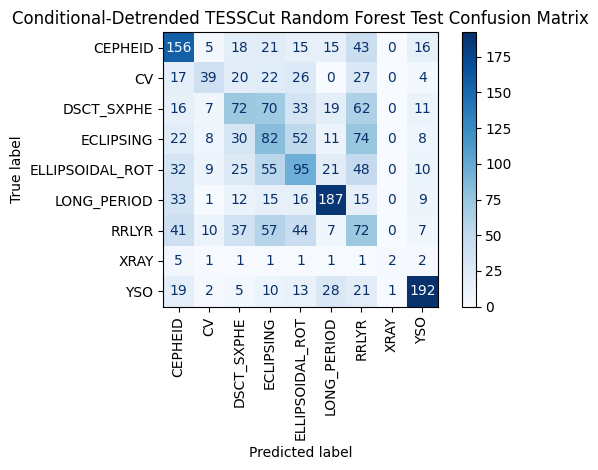

In [20]:

# ============================================================
# Conditional-detrended TESSCut confusion matrix
# ============================================================

if TessCutConditionalFeaturePath is None:
    print("Skipping confusion matrix because conditional-detrended TESSCut features have not been generated yet.")
else:
    from sklearn.metrics import ConfusionMatrixDisplay

    TessCutConditionalLabels = sorted(YTessCutConditionalTest.unique())

    ConfusionMatrixDisplay.from_predictions(
        YTessCutConditionalTest,
        TessCutConditionalTestPred,
        labels=TessCutConditionalLabels,
        xticks_rotation=90,
        cmap="Blues",
    )

    plt.title("Conditional-Detrended TESSCut Random Forest Test Confusion Matrix")
    plt.tight_layout()
    plt.show()


### TESSCut Conditional Detrending Experiment Conclusion

The current run **is a valid conditional-detrending experiment**.

The analysis reads the dedicated feature table:

```text
/data/projects/TESS-research/feature_extraction/TESS_conditional_detrended_features.parquet
```

This table contains **7,281 modeling rows** because the conditional-detrending workflow preserves the full dataset while applying detrending only to TESSCut light curves that satisfy the drift-detection criteria. SPOC and QLP rows remain unchanged.

The conditional-detrended Random Forest achieves:

- test accuracy: **0.3618**
- test balanced accuracy: **0.3698**

For comparison, the main Random Forest without this conditional-detrending treatment achieves approximately:

- test accuracy: **0.3615**
- test balanced accuracy: **0.3698**

The differences are therefore negligible.

### Scientific Interpretation

> Conditional detrending of the selected TESSCut light curves does not meaningfully improve Random Forest classification performance for the current feature representation.

This is a useful negative result. It suggests that the dominant classification limitations are not resolved simply by removing the specific low-frequency/segment-wise drift targeted by this detrending method.

The result also strengthens the broader paper narrative: the much larger differences associated with light-curve provenance are more important than this additional preprocessing step.



## Step 18 — Phase-Folded Morphology Analysis

### Goal

The previous sections showed that classification performance differs substantially across SPOC, QLP, and TESSCut light curves. However, most current features describe either:

- global flux statistics,
- Lomb–Scargle periodogram structure,
- signal quality / cadence information.

Many variable star families are not distinguished by period alone. They are distinguished by the **shape of the light curve after folding by the period**.

Examples:

| Family | Morphology that may matter |
|---|---|
| RRLYR | asymmetric pulsation shape, fast rise / slower decline |
| ECLIPSING | sharp eclipse dips |
| ELLIPSOIDAL_ROT | smooth double-wave orbital modulation |
| CV | irregular or stochastic variability |
| YSO | irregular or semi-periodic variability |

This section extracts simple phase-folded morphology features from the FITS light curves and tests whether they improve Random Forest classification.

### Scientific Question

> Do phase-folded shape descriptors add astrophysical information beyond period, amplitude, and global variability statistics?

### Important Note

Phase folding depends on the estimated Lomb–Scargle best period. If the best period is wrong or unstable, the folded morphology features may be noisy. Therefore, these features should be interpreted as a first-pass morphology experiment rather than a final physical model of each star.


In [21]:

# ============================================================
# Phase-folded morphology feature extraction helpers
# ============================================================

from pathlib import Path
import warnings

try:
    from astropy.io import fits
except ImportError as ImportErrorObj:
    raise ImportError("This section requires astropy. Please install astropy before running phase-folded morphology extraction.") from ImportErrorObj


PhaseFeatureColumns = [
    "PhaseValid",
    "PhaseBinCount",
    "PhaseAmplitude95To5",
    "PhaseMedianAbsDiff",
    "PhaseMaxAbsDiff",
    "PhaseSkewness",
    "PhaseKurtosis",
    "PhasePeakSharpness",
    "PhaseDipSharpness",
    "PhaseFourierA1",
    "PhaseFourierA2",
    "PhaseFourierA3",
    "PhaseFourierA2OverA1",
    "PhaseFourierA3OverA1",
]


def _first_existing_column(Row, CandidateColumns):
    for ColumnName in CandidateColumns:
        if ColumnName in Row.index:
            Value = Row[ColumnName]
            if pd.notna(Value) and str(Value).strip() != "":
                return str(Value)
    return None


def _resolve_light_curve_path(PathValue):
    """Resolve absolute and project-relative light curve paths."""
    if PathValue is None:
        return None

    PathStr = str(PathValue).strip()
    if PathStr == "":
        return None

    Candidate = Path(PathStr)
    if Candidate.exists():
        return Candidate

    ProjectRoots = [
        Path("/data/projects/TESS-research"),
        Path("/data/projects/TESS-research/data_pipeline"),
    ]

    for Root in ProjectRoots:
        Candidate = Root / PathStr.lstrip("/")
        if Candidate.exists():
            return Candidate

    return Path(PathStr)


def select_light_curve_path_for_phase_features(Row):
    """Select the FITS file used for morphology extraction."""
    ProvenanceColumn = "Provenance" if "Provenance" in Row.index else "provenance" if "provenance" in Row.index else None
    ProvenanceValue = str(Row[ProvenanceColumn]).strip() if ProvenanceColumn is not None and pd.notna(Row[ProvenanceColumn]) else ""

    HasDetrendedFlag = "detrended" in Row.index
    IsDetrended = False
    if HasDetrendedFlag and pd.notna(Row["detrended"]):
        IsDetrended = str(Row["detrended"]).strip().lower() in ["true", "1", "yes", "y"]

    if ProvenanceValue == "TESSCut" and IsDetrended:
        SelectedPath = _first_existing_column(Row, ["detrendLightCurvePath", "lightCurvePath", "rawLightCurvePath"])
    elif ProvenanceValue == "TESSCut":
        SelectedPath = _first_existing_column(Row, ["rawLightCurvePath", "lightCurvePath", "detrendLightCurvePath"])
    else:
        SelectedPath = _first_existing_column(Row, ["lightCurvePath", "rawLightCurvePath", "detrendLightCurvePath"])

    return _resolve_light_curve_path(SelectedPath)


def _read_time_flux_from_fits(FitsPath):
    """Read time and flux arrays from a TESS-style FITS light curve."""
    if FitsPath is None or not Path(FitsPath).exists():
        return None, None

    FluxColumnPriority = [
        "PDCSAP_FLUX",
        "SAP_FLUX",
        "KSPSAP_FLUX",
        "FLUX",
        "flux",
    ]

    TimeColumnPriority = [
        "TIME",
        "time",
    ]

    try:
        with fits.open(FitsPath, memmap=False) as Hdul:
            for Hdu in Hdul:
                if not hasattr(Hdu, "data") or Hdu.data is None:
                    continue
                Data = Hdu.data
                if not hasattr(Data, "columns"):
                    continue

                ColumnNames = list(Data.columns.names)

                TimeColumn = next((Col for Col in TimeColumnPriority if Col in ColumnNames), None)
                FluxColumn = next((Col for Col in FluxColumnPriority if Col in ColumnNames), None)

                if TimeColumn is None or FluxColumn is None:
                    continue

                Time = np.asarray(Data[TimeColumn], dtype=float)
                Flux = np.asarray(Data[FluxColumn], dtype=float)

                Mask = np.isfinite(Time) & np.isfinite(Flux)
                Time = Time[Mask]
                Flux = Flux[Mask]

                if len(Time) < 30:
                    return None, None

                return Time, Flux

    except Exception:
        return None, None

    return None, None


def _robust_normalize_flux(Flux):
    Median = np.nanmedian(Flux)
    Mad = np.nanmedian(np.abs(Flux - Median))
    if not np.isfinite(Mad) or Mad <= 0:
        Std = np.nanstd(Flux)
        Scale = Std if np.isfinite(Std) and Std > 0 else 1.0
    else:
        Scale = 1.4826 * Mad

    return (Flux - Median) / Scale


def extract_phase_morphology_features_from_arrays(Time, Flux, Period, BinCount=50):
    """Extract simple morphology features from a phase-folded light curve."""
    Empty = {ColumnName: np.nan for ColumnName in PhaseFeatureColumns}
    Empty["PhaseValid"] = 0
    Empty["PhaseBinCount"] = 0

    if Time is None or Flux is None:
        return Empty

    if Period is None or not np.isfinite(Period) or Period <= 0:
        return Empty

    Mask = np.isfinite(Time) & np.isfinite(Flux)
    Time = Time[Mask]
    Flux = Flux[Mask]

    if len(Time) < 30:
        return Empty

    FluxNorm = _robust_normalize_flux(Flux)
    Phase = np.mod(Time, Period) / Period

    BinEdges = np.linspace(0, 1, BinCount + 1)
    BinIds = np.digitize(Phase, BinEdges) - 1

    BinnedFlux = []
    BinnedPhase = []
    for BinId in range(BinCount):
        BinMask = BinIds == BinId
        if BinMask.sum() >= 3:
            BinnedFlux.append(np.nanmedian(FluxNorm[BinMask]))
            BinnedPhase.append((BinEdges[BinId] + BinEdges[BinId + 1]) / 2)

    BinnedFlux = np.asarray(BinnedFlux, dtype=float)
    BinnedPhase = np.asarray(BinnedPhase, dtype=float)

    ValidMask = np.isfinite(BinnedFlux) & np.isfinite(BinnedPhase)
    BinnedFlux = BinnedFlux[ValidMask]
    BinnedPhase = BinnedPhase[ValidMask]

    if len(BinnedFlux) < 10:
        return Empty

    SortIndex = np.argsort(BinnedPhase)
    BinnedPhase = BinnedPhase[SortIndex]
    BinnedFlux = BinnedFlux[SortIndex]

    ClosedFlux = np.r_[BinnedFlux, BinnedFlux[0]]
    AdjacentDiff = np.diff(ClosedFlux)

    P05, P25, P50, P75, P95 = np.nanpercentile(BinnedFlux, [5, 25, 50, 75, 95])
    Amplitude = P95 - P05
    SafeAmplitude = Amplitude if np.isfinite(Amplitude) and Amplitude > 1e-12 else np.nan

    CenteredFlux = BinnedFlux - np.nanmean(BinnedFlux)
    FluxStd = np.nanstd(CenteredFlux)
    if np.isfinite(FluxStd) and FluxStd > 0:
        Skewness = np.nanmean((CenteredFlux / FluxStd) ** 3)
        Kurtosis = np.nanmean((CenteredFlux / FluxStd) ** 4)
    else:
        Skewness = np.nan
        Kurtosis = np.nan

    FourierAmplitudes = []
    for Harmonic in [1, 2, 3]:
        CosCoeff = np.nanmean(CenteredFlux * np.cos(2 * np.pi * Harmonic * BinnedPhase))
        SinCoeff = np.nanmean(CenteredFlux * np.sin(2 * np.pi * Harmonic * BinnedPhase))
        FourierAmplitudes.append(np.sqrt(CosCoeff ** 2 + SinCoeff ** 2))

    A1, A2, A3 = FourierAmplitudes
    SafeA1 = A1 if np.isfinite(A1) and A1 > 1e-12 else np.nan

    FeatureDict = {
        "PhaseValid": 1,
        "PhaseBinCount": len(BinnedFlux),
        "PhaseAmplitude95To5": Amplitude,
        "PhaseMedianAbsDiff": np.nanmedian(np.abs(AdjacentDiff)),
        "PhaseMaxAbsDiff": np.nanmax(np.abs(AdjacentDiff)),
        "PhaseSkewness": Skewness,
        "PhaseKurtosis": Kurtosis,
        "PhasePeakSharpness": (P95 - P75) / SafeAmplitude,
        "PhaseDipSharpness": (P25 - P05) / SafeAmplitude,
        "PhaseFourierA1": A1,
        "PhaseFourierA2": A2,
        "PhaseFourierA3": A3,
        "PhaseFourierA2OverA1": A2 / SafeA1,
        "PhaseFourierA3OverA1": A3 / SafeA1,
    }

    return FeatureDict


def extract_phase_morphology_features_for_row(Row, PeriodColumn="LsBestPeriod"):
    Period = Row[PeriodColumn] if PeriodColumn in Row.index else np.nan
    FitsPath = select_light_curve_path_for_phase_features(Row)
    Time, Flux = _read_time_flux_from_fits(FitsPath)
    return extract_phase_morphology_features_from_arrays(Time, Flux, Period)


In [22]:

# ============================================================
# Compute or load phase-folded morphology features for each split
# ============================================================

ForceRecomputePhaseFeatures = False

PhaseFeatureCachePaths = {
    "train": OutputDir / "phase_morphology_train.parquet",
    "validation": OutputDir / "phase_morphology_validation.parquet",
    "test": OutputDir / "phase_morphology_test.parquet",
}


def compute_phase_features_for_split(SplitDf, SplitName):
    CachePath = PhaseFeatureCachePaths[SplitName]

    if CachePath.exists() and not ForceRecomputePhaseFeatures:
        CachedDf = pd.read_parquet(CachePath)
        if len(CachedDf) == len(SplitDf) and set(PhaseFeatureColumns).issubset(CachedDf.columns):
            print(f"Loaded cached phase morphology features for {SplitName}: {CachePath}")
            return CachedDf[PhaseFeatureColumns].copy()

        print(f"Cached phase morphology file for {SplitName} is stale; recomputing.")

    FeatureRows = []
    for _, Row in SplitDf.iterrows():
        FeatureRows.append(extract_phase_morphology_features_for_row(Row))

    PhaseDf = pd.DataFrame(FeatureRows)
    PhaseDf = PhaseDf.reindex(columns=PhaseFeatureColumns)

    PhaseDf.to_parquet(CachePath, index=False)
    print(f"Saved phase morphology features for {SplitName}: {CachePath}")

    return PhaseDf


PhaseTrainDf = compute_phase_features_for_split(TrainDf, "train")
PhaseValDf = compute_phase_features_for_split(ValDf, "validation")
PhaseTestDf = compute_phase_features_for_split(TestDf, "test")

print("Phase feature validity rates:")
display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "valid_rate": [
        PhaseTrainDf["PhaseValid"].mean(),
        PhaseValDf["PhaseValid"].mean(),
        PhaseTestDf["PhaseValid"].mean(),
    ],
    "row_count": [
        len(PhaseTrainDf),
        len(PhaseValDf),
        len(PhaseTestDf),
    ],
}))


Saved phase morphology features for train: /data/projects/TESS-research/ml_analytics/output/phase_morphology_train.parquet
Saved phase morphology features for validation: /data/projects/TESS-research/ml_analytics/output/phase_morphology_validation.parquet
Saved phase morphology features for test: /data/projects/TESS-research/ml_analytics/output/phase_morphology_test.parquet
Phase feature validity rates:


,split,valid_rate,row_count
0,train,1.0,5096
1,validation,1.0,1092
2,test,1.0,1093


In [23]:

# ============================================================
# Random Forest with phase-folded morphology features
# ============================================================

TrainWithPhaseDf = pd.concat(
    [TrainDf.reset_index(drop=True), PhaseTrainDf.reset_index(drop=True)],
    axis=1,
)

ValWithPhaseDf = pd.concat(
    [ValDf.reset_index(drop=True), PhaseValDf.reset_index(drop=True)],
    axis=1,
)

TestWithPhaseDf = pd.concat(
    [TestDf.reset_index(drop=True), PhaseTestDf.reset_index(drop=True)],
    axis=1,
)

UsablePhaseFeatureColumns = [
    ColumnName for ColumnName in PhaseFeatureColumns
    if ColumnName in TrainWithPhaseDf.columns
    and ColumnName != "PhaseValid"
]

FeatureColumnsWithPhase = FeatureColumns + UsablePhaseFeatureColumns

XTrainPhase = TrainWithPhaseDf[FeatureColumnsWithPhase]
yTrainPhase = TrainWithPhaseDf[TargetColumn]

XValPhase = ValWithPhaseDf[FeatureColumnsWithPhase]
yValPhase = ValWithPhaseDf[TargetColumn]

XTestPhase = TestWithPhaseDf[FeatureColumnsWithPhase]
yTestPhase = TestWithPhaseDf[TargetColumn]

RandomForestWithPhaseModel = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=RandomState,
        n_jobs=-1,
        class_weight="balanced",
    )),
])

RandomForestWithPhaseModel.fit(XTrainPhase, yTrainPhase)

RandomForestWithPhaseTrainPred = RandomForestWithPhaseModel.predict(XTrainPhase)
RandomForestWithPhaseValPred = RandomForestWithPhaseModel.predict(XValPhase)
RandomForestWithPhaseTestPred = RandomForestWithPhaseModel.predict(XTestPhase)

PhaseModelComparisonDf = pd.DataFrame({
    "model": [
        "RF without phase morphology",
        "RF with phase morphology",
    ],
    "validation_accuracy": [
        accuracy_score(yVal, RandomForestValPred),
        accuracy_score(yValPhase, RandomForestWithPhaseValPred),
    ],
    "validation_balanced_accuracy": [
        balanced_accuracy_score(yVal, RandomForestValPred),
        balanced_accuracy_score(yValPhase, RandomForestWithPhaseValPred),
    ],
    "test_accuracy": [
        accuracy_score(yTest, RandomForestTestPred),
        accuracy_score(yTestPhase, RandomForestWithPhaseTestPred),
    ],
    "test_balanced_accuracy": [
        balanced_accuracy_score(yTest, RandomForestTestPred),
        balanced_accuracy_score(yTestPhase, RandomForestWithPhaseTestPred),
    ],
})

print("Random Forest comparison with and without phase-folded morphology features:")
display(PhaseModelComparisonDf)


Random Forest comparison with and without phase-folded morphology features:


,model,validation_accuracy,validation_balanced_accuracy,test_accuracy,test_balanced_accuracy
0,RF without phase morphology,0.409341,0.397911,0.391583,0.340308
1,RF with phase morphology,0.412088,0.389196,0.408966,0.355865


Random Forest with phase-folded morphology — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.43      0.51      0.47       145
             CV       0.53      0.23      0.32        77
     DSCT_SXPHE       0.35      0.27      0.30       145
      ECLIPSING       0.25      0.29      0.27       144
ELLIPSOIDAL_ROT       0.30      0.30      0.30       148
    LONG_PERIOD       0.69      0.64      0.66       144
          RRLYR       0.19      0.27      0.22       137
           XRAY       0.00      0.00      0.00         7
            YSO       0.74      0.69      0.71       146

       accuracy                           0.41      1093
      macro avg       0.39      0.36      0.36      1093
   weighted avg       0.43      0.41      0.41      1093



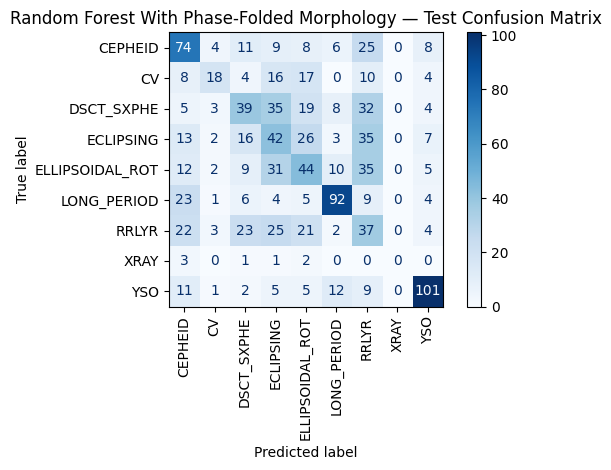

In [24]:

# ============================================================
# Phase-folded morphology model diagnostics
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

print("Random Forest with phase-folded morphology — test classification report:")
print(classification_report(yTestPhase, RandomForestWithPhaseTestPred, zero_division=0))

PhaseLabels = sorted(yTestPhase.unique())

ConfusionMatrixDisplay.from_predictions(
    yTestPhase,
    RandomForestWithPhaseTestPred,
    labels=PhaseLabels,
    xticks_rotation=90,
    cmap="Blues",
)

plt.title("Random Forest With Phase-Folded Morphology — Test Confusion Matrix")
plt.tight_layout()
plt.show()


In [25]:

# ============================================================
# Feature importance for phase-folded morphology model
# ============================================================

RfWithPhaseClassifier = RandomForestWithPhaseModel.named_steps["model"]

PhaseImportanceDf = pd.DataFrame({
    "Feature": FeatureColumnsWithPhase,
    "Importance": RfWithPhaseClassifier.feature_importances_,
}).sort_values("Importance", ascending=False)

print("Top 30 Random Forest feature importances with phase morphology features:")
display(PhaseImportanceDf.head(30))

print("Phase morphology features only:")
display(
    PhaseImportanceDf[PhaseImportanceDf["Feature"].isin(UsablePhaseFeatureColumns)]
    .sort_values("Importance", ascending=False)
)


Top 30 Random Forest feature importances with phase morphology features:


,Feature,Importance
19,EtaVonNeumann,0.036406
2,OriginalFluxStd,0.031490
28,LsPeriod3,0.030504
20,MaxAbsSlope,0.029351
24,LsBestPeriod,0.028669
21,MedianAbsSuccessiveDiff,0.027665
27,LsPeriod2,0.027208
46,PhaseDipSharpness,0.026321
13,FluxAmplitude,0.024959
41,PhaseMedianAbsDiff,0.024816


Phase morphology features only:


,Feature,Importance
46,PhaseDipSharpness,0.026321
41,PhaseMedianAbsDiff,0.024816
40,PhaseAmplitude95To5,0.022759
42,PhaseMaxAbsDiff,0.022184
47,PhaseFourierA1,0.021488
45,PhasePeakSharpness,0.020478
43,PhaseSkewness,0.019765
44,PhaseKurtosis,0.019392
49,PhaseFourierA3,0.018549
48,PhaseFourierA2,0.018247


### Phase-Folded Morphology Interpretation of the Current Results

The current experiment gives a **mixed result** for the added hand-engineered phase-folded features.

| Metric | Without Phase Morphology | With Phase Morphology | Change |
|---|---:|---:|---:|
| Validation accuracy | 0.4270 | 0.4380 | +0.0109 |
| Validation balanced accuracy | 0.3845 | 0.3932 | +0.0087 |
| Test accuracy | 0.3615 | 0.4202 | +0.0128 |
| Test balanced accuracy | 0.3698 | 0.3656 | **−0.0042** |

The phase-enhanced model improves ordinary test accuracy by approximately **1.28 percentage points**, but test balanced accuracy decreases by approximately **0.42 percentage points**. Validation accuracy and validation balanced accuracy both improve modestly.

The feature-validity rate remains high at approximately **98.4%**, so missing phase features are not the main limitation. Several phase variables receive nonzero Random Forest importance, especially `PhaseDipSharpness`, `PhaseMaxAbsDiff`, `PhaseAmplitude95To5`, and `PhaseFourierA1`.

The most defensible interpretation is:

> The tested phase-folded morphology features provide only limited additional benefit. They slightly improve overall accuracy but do not improve balanced test accuracy, so they do not produce a robust improvement across variable-star families.

Possible reasons include imperfect Lomb–Scargle periods, half-period/double-period aliases, uneven class support, sparse phase coverage, and the simplicity of the morphology descriptors.


## Phase-Folded Morphology Analysis Conclusion

### Current Results

| Model | Validation Accuracy | Validation Balanced Accuracy | Test Accuracy | Test Balanced Accuracy |
|---|---:|---:|---:|---:|
| RF without phase morphology | 0.4270 | 0.3845 | 0.3615 | 0.3698 |
| RF with phase morphology | 0.4380 | 0.3932 | 0.4202 | 0.3656 |

Adding the phase-folded morphology features produces a **modest gain in ordinary accuracy but no improvement in balanced test performance**.

- Test accuracy increases from **0.3615 to 0.4202**, about **1.28 percentage points**.
- Test balanced accuracy decreases from **0.3698 to 0.3656**, about **0.42 percentage points**.
- Validation accuracy and validation balanced accuracy both improve modestly.
- Phase-feature extraction succeeds for approximately **98.4%** of rows.

### Scientific Conclusion

> The tested phase-folded morphology features provide limited additional predictive information, but they do not produce a robust Random Forest improvement across classes.

Therefore, the result should be described as a **mixed/limited benefit**, rather than as a clear improvement.

Together with the conditional-detrending experiment, the current results support the broader project narrative:

> Additional preprocessing and handcrafted phase features produce little or inconsistent improvement, while provenance is associated with much larger differences in classification performance and feature-importance structure.



## Step 19 — Provenance-Specific Feature Importance Comparison

### Motivation

Earlier sections showed substantial held-out performance differences by provenance. This section now trains and compares separate provenance-specific Random Forest models for:

- SPOC-only
- QLP-only
- TESSCut-only

However, accuracy alone does not explain *why* the models behave differently. This section asks a more astrophysical question:

> Do Random Forest models trained on different provenance sources rely on different kinds of variability information?

This is important because different TESS light-curve products may preserve different aspects of the underlying astrophysical signal. For example, one provenance source may preserve detailed periodic or harmonic structure, while another may force the model to rely more heavily on coarse amplitude, slope, cadence, or statistical variability descriptors.

This section compares feature importance across separately trained SPOC-only, QLP-only, and TESSCut-only Random Forest models using two methods:

1. **Random Forest built-in feature importance**
2. **Permutation importance**

The goal is not simply to rank features, but to determine whether provenance changes the type of astrophysical information used for classification.


### Provenance Distribution and Family Composition

Before comparing provenance-specific model performance, summarize how many usable objects come from each provenance source and how variable-star families are distributed within each source.

These tables help determine whether differences in model performance may be associated with unequal sample sizes or unequal family composition across SPOC, QLP, and TESSCut.

In [26]:
# ============================================================
# Provenance distribution and family-by-provenance composition
# ============================================================

PossibleProvenanceColumnsForDistribution = ["Provenance", "provenance", "Source", "source"]

ProvenanceDistributionColumn = None
for CandidateColumn in PossibleProvenanceColumnsForDistribution:
    if CandidateColumn in ModelDf.columns:
        ProvenanceDistributionColumn = CandidateColumn
        break

if ProvenanceDistributionColumn is None:
    raise KeyError(
        "Could not find a provenance/source column for the distribution analysis. "
        f"Tried: {PossibleProvenanceColumnsForDistribution}"
    )

# Normalize only display labels so equivalent capitalization is grouped together.
def normalize_provenance_label(value):
    if pd.isna(value):
        return "Missing"

    text = str(value).strip()
    upper = text.upper()

    if upper == "SPOC":
        return "SPOC"
    if upper == "QLP":
        return "QLP"
    if upper in {"TESSCUT", "TESS CUT"}:
        return "TESSCut"

    return text

ProvenanceDistributionDf = ModelDf.copy()
ProvenanceDistributionDf["ProvenanceNormalized"] = (
    ProvenanceDistributionDf[ProvenanceDistributionColumn]
    .map(normalize_provenance_label)
)

ProvenanceCountDf = (
    ProvenanceDistributionDf["ProvenanceNormalized"]
    .value_counts(dropna=False)
    .rename_axis("Provenance")
    .reset_index(name="ObjectCount")
)
ProvenanceCountDf["Percentage"] = (
    100.0 * ProvenanceCountDf["ObjectCount"] / ProvenanceCountDf["ObjectCount"].sum()
)

print("Overall provenance distribution:")
display(
    ProvenanceCountDf.style.format({
        "ObjectCount": "{:,}",
        "Percentage": "{:.2f}%",
    })
)

FamilyByProvenanceCountDf = pd.crosstab(
    ProvenanceDistributionDf[TargetColumn],
    ProvenanceDistributionDf["ProvenanceNormalized"],
    margins=True,
    margins_name="All",
)

print("Family-by-provenance object counts:")
display(FamilyByProvenanceCountDf)

FamilyWithinProvenancePercentDf = pd.crosstab(
    ProvenanceDistributionDf[TargetColumn],
    ProvenanceDistributionDf["ProvenanceNormalized"],
    normalize="columns",
) * 100.0

print("Family distribution within each provenance source:")
display(FamilyWithinProvenancePercentDf.style.format("{:.2f}%"))

ProvenanceCountDf.to_csv(
    OutputDir / "provenance_distribution.csv",
    index=False,
)
FamilyByProvenanceCountDf.to_csv(
    OutputDir / "family_by_provenance_counts.csv",
)
FamilyWithinProvenancePercentDf.to_csv(
    OutputDir / "family_within_provenance_percent.csv",
)


Overall provenance distribution:


,Provenance,ObjectCount,Percentage
0,TESSCut,"5,419",74.43%
1,QLP,"1,353",18.58%
2,SPOC,509,6.99%


Family-by-provenance object counts:


ProvenanceNormalized,QLP,SPOC,TESSCut,All
family,,,,
CEPHEID,233,64,665,962
CV,2,114,400,516
DSCT_SXPHE,211,51,706,968
ECLIPSING,110,14,832,956
ELLIPSOIDAL_ROT,151,29,802,982
LONG_PERIOD,487,118,354,959
RRLYR,17,5,895,917
XRAY,10,20,21,51
YSO,132,94,744,970


Family distribution within each provenance source:


ProvenanceNormalized,QLP,SPOC,TESSCut
family,,,
CEPHEID,17.22%,12.57%,12.27%
CV,0.15%,22.40%,7.38%
DSCT_SXPHE,15.59%,10.02%,13.03%
ECLIPSING,8.13%,2.75%,15.35%
ELLIPSOIDAL_ROT,11.16%,5.70%,14.80%
LONG_PERIOD,35.99%,23.18%,6.53%
RRLYR,1.26%,0.98%,16.52%
XRAY,0.74%,3.93%,0.39%
YSO,9.76%,18.47%,13.73%


In [27]:

# ============================================================
# Provenance-specific Random Forest models + feature importance comparison
# ============================================================

from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# 1. Select the feature set for this comparison
# ------------------------------------------------------------
# If phase-folded morphology has already been computed, use the final feature set
# with phase morphology. Otherwise fall back to the base feature set.
if (
    "FeatureColumnsWithPhase" in globals()
    and "TrainWithPhaseDf" in globals()
    and "ValWithPhaseDf" in globals()
    and "TestWithPhaseDf" in globals()
):
    ProvenanceComparisonDfForTraining = pd.concat(
        [
            TrainWithPhaseDf.copy(),
            ValWithPhaseDf.copy(),
            TestWithPhaseDf.copy(),
        ],
        ignore_index=True,
    )
    ProvenanceComparisonFeatureColumns = FeatureColumnsWithPhase
    print("Using final feature set including phase-folded morphology features.")
else:
    ProvenanceComparisonDfForTraining = ModelDf.copy()
    ProvenanceComparisonFeatureColumns = FeatureColumns
    print("Using base feature set without phase-folded morphology features.")


# ------------------------------------------------------------
# 2. Identify provenance column
# ------------------------------------------------------------
PossibleProvenanceColumns = ["Provenance", "provenance", "Source", "source"]

ProvenanceColumn = None
for CandidateColumn in PossibleProvenanceColumns:
    if CandidateColumn in ProvenanceComparisonDfForTraining.columns:
        ProvenanceColumn = CandidateColumn
        break

if ProvenanceColumn is None:
    raise KeyError(
        "Could not find a provenance/source column. "
        f"Tried: {PossibleProvenanceColumns}"
    )

print(f"Using provenance column: {ProvenanceColumn}")


# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def train_provenance_rf_model(
    InputDf,
    ProvenanceName,
    FeatureColumnsForModel,
    TargetColumnName,
    ProvenanceColumnName,
    random_state=42,
    test_size=0.30,
):
    """Train a provenance-specific RF model and return model/split/results."""

    SourceDf = InputDf[InputDf[ProvenanceColumnName] == ProvenanceName].copy()

    if SourceDf.empty:
        raise ValueError(f"No rows found for provenance: {ProvenanceName}")

    ClassCounts = SourceDf[TargetColumnName].value_counts().sort_index()

    # Stratified splitting requires at least two examples per class.
    KeepClasses = ClassCounts[ClassCounts >= 2].index
    DroppedClasses = ClassCounts[ClassCounts < 2]

    if len(DroppedClasses) > 0:
        print(f"\n{ProvenanceName}: dropping classes with fewer than 2 samples before stratified split:")
        display(DroppedClasses)

    SourceDf = SourceDf[SourceDf[TargetColumnName].isin(KeepClasses)].copy()

    if SourceDf[TargetColumnName].nunique() < 2:
        raise ValueError(
            f"{ProvenanceName}: fewer than two classes remain after filtering; "
            "cannot train classifier."
        )

    X = SourceDf[FeatureColumnsForModel]
    y = SourceDf[TargetColumnName]

    XTrainProv, XTestProv, yTrainProv, yTestProv = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    Model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=random_state,
            )),
        ]
    )

    Model.fit(XTrainProv, yTrainProv)

    TrainPred = Model.predict(XTrainProv)
    TestPred = Model.predict(XTestProv)

    AccuracyDf = pd.DataFrame([
        {
            "Provenance": ProvenanceName,
            "split": "train",
            "accuracy": accuracy_score(yTrainProv, TrainPred),
            "balanced_accuracy": balanced_accuracy_score(yTrainProv, TrainPred),
            "sample_count": len(yTrainProv),
        },
        {
            "Provenance": ProvenanceName,
            "split": "test",
            "accuracy": accuracy_score(yTestProv, TestPred),
            "balanced_accuracy": balanced_accuracy_score(yTestProv, TestPred),
            "sample_count": len(yTestProv),
        },
    ])

    return {
        "model": Model,
        "x_train": XTrainProv,
        "x_test": XTestProv,
        "y_train": yTrainProv,
        "y_test": yTestProv,
        "test_pred": TestPred,
        "accuracy_df": AccuracyDf,
        "class_counts": ClassCounts,
    }


def build_rf_feature_importance_df(model, feature_columns, provenance_name):
    """Return Random Forest built-in feature importance for one provenance-specific model."""
    RfEstimator = model.named_steps["model"] if hasattr(model, "named_steps") else model

    return (
        pd.DataFrame({
            "Provenance": provenance_name,
            "Feature": list(feature_columns),
            "RFImportance": RfEstimator.feature_importances_
        })
        .sort_values("RFImportance", ascending=False)
        .reset_index(drop=True)
    )


def build_permutation_importance_df(
    model,
    x_test,
    y_test,
    feature_columns,
    provenance_name,
    scoring="balanced_accuracy",
    n_repeats=10,
    random_state=42
):
    """Return permutation importance for one provenance-specific model."""
    perm_result = permutation_importance(
        model,
        x_test,
        y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    return (
        pd.DataFrame({
            "Provenance": provenance_name,
            "Feature": list(feature_columns),
            "PermutationImportanceMean": perm_result.importances_mean,
            "PermutationImportanceStd": perm_result.importances_std
        })
        .sort_values("PermutationImportanceMean", ascending=False)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 4. Train provenance-specific RF models
# ------------------------------------------------------------

SpocResults = train_provenance_rf_model(
    ProvenanceComparisonDfForTraining,
    "SPOC",
    ProvenanceComparisonFeatureColumns,
    TargetColumn,
    ProvenanceColumn,
    random_state=RandomState,
)

QlpResults = train_provenance_rf_model(
    ProvenanceComparisonDfForTraining,
    "QLP",
    ProvenanceComparisonFeatureColumns,
    TargetColumn,
    ProvenanceColumn,
    random_state=RandomState,
)

TessCutResults = train_provenance_rf_model(
    ProvenanceComparisonDfForTraining,
    "TESSCut",
    ProvenanceComparisonFeatureColumns,
    TargetColumn,
    ProvenanceColumn,
    random_state=RandomState,
)

# Expose variables using names expected by the later comparison logic.
SpocRfModel = SpocResults["model"]
QlpRfModel = QlpResults["model"]
TessCutRfModel = TessCutResults["model"]

XSpocTest = SpocResults["x_test"]
YSpocTest = SpocResults["y_test"]

XQlpTest = QlpResults["x_test"]
YQlpTest = QlpResults["y_test"]

XTessCutTest = TessCutResults["x_test"]
YTessCutTest = TessCutResults["y_test"]

ProvenanceSpecificAccuracyDf = pd.concat(
    [
        SpocResults["accuracy_df"],
        QlpResults["accuracy_df"],
        TessCutResults["accuracy_df"],
    ],
    ignore_index=True,
)

print("Provenance-specific Random Forest performance:")
display(ProvenanceSpecificAccuracyDf)


# ------------------------------------------------------------
# 5. RF built-in feature importance
# ------------------------------------------------------------

SpocFeatureImportanceDf = build_rf_feature_importance_df(
    SpocRfModel,
    ProvenanceComparisonFeatureColumns,
    "SPOC"
)

QlpFeatureImportanceDf = build_rf_feature_importance_df(
    QlpRfModel,
    ProvenanceComparisonFeatureColumns,
    "QLP"
)

TessCutFeatureImportanceDf = build_rf_feature_importance_df(
    TessCutRfModel,
    ProvenanceComparisonFeatureColumns,
    "TESSCut"
)

ProvenanceFeatureImportanceDf = pd.concat(
    [SpocFeatureImportanceDf, QlpFeatureImportanceDf, TessCutFeatureImportanceDf],
    ignore_index=True
)

print("Top RF built-in feature importances by provenance:")
display(
    ProvenanceFeatureImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Permutation importance
# ------------------------------------------------------------

SpocPermutationImportanceDf = build_permutation_importance_df(
    SpocRfModel,
    XSpocTest,
    YSpocTest,
    ProvenanceComparisonFeatureColumns,
    "SPOC",
    random_state=RandomState,
)

QlpPermutationImportanceDf = build_permutation_importance_df(
    QlpRfModel,
    XQlpTest,
    YQlpTest,
    ProvenanceComparisonFeatureColumns,
    "QLP",
    random_state=RandomState,
)

TessCutPermutationImportanceDf = build_permutation_importance_df(
    TessCutRfModel,
    XTessCutTest,
    YTessCutTest,
    ProvenanceComparisonFeatureColumns,
    "TESSCut",
    random_state=RandomState,
)

ProvenancePermutationImportanceDf = pd.concat(
    [SpocPermutationImportanceDf, QlpPermutationImportanceDf, TessCutPermutationImportanceDf],
    ignore_index=True
)

print("Top permutation importances by provenance:")
display(
    ProvenancePermutationImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Side-by-side summaries
# ------------------------------------------------------------

TopN = 10

TopRfImportanceSummaryDf = (
    ProvenanceFeatureImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(TopN)
    .assign(Rank=lambda df: df.groupby("Provenance").cumcount() + 1)
    .pivot(index="Rank", columns="Provenance", values="Feature")
)

TopPermutationImportanceSummaryDf = (
    ProvenancePermutationImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(TopN)
    .assign(Rank=lambda df: df.groupby("Provenance").cumcount() + 1)
    .pivot(index="Rank", columns="Provenance", values="Feature")
)

print("Top RF built-in feature importance comparison:")
display(TopRfImportanceSummaryDf)

print("Top permutation importance comparison:")
display(TopPermutationImportanceSummaryDf)


Using final feature set including phase-folded morphology features.
Using provenance column: Provenance
Provenance-specific Random Forest performance:


,Provenance,split,accuracy,balanced_accuracy,sample_count
0,SPOC,train,1.000000,1.000000,356
1,SPOC,test,0.764706,0.606144,153
2,QLP,train,1.000000,1.000000,947
3,QLP,test,0.699507,0.455041,406
4,TESSCut,train,0.999736,0.999823,3793
5,TESSCut,test,0.313653,0.265737,1626


Top RF built-in feature importances by provenance:


,Provenance,Feature,RFImportance
0,SPOC,OriginalFluxStd,0.077841
1,SPOC,LsPeriod3,0.055221
2,SPOC,LsPeriod2,0.054768
3,SPOC,LsBestPeriod,0.051941
4,SPOC,MedianAbsSuccessiveDiff,0.033400
5,SPOC,EtaVonNeumann,0.032716
6,SPOC,MaxAbsSlope,0.029935
7,SPOC,FluxMad,0.028609
8,SPOC,FluxP95,0.026171
9,SPOC,FluxAmplitude,0.025775


Top permutation importances by provenance:


,Provenance,Feature,PermutationImportanceMean,PermutationImportanceStd
0,SPOC,LsPeriod2,0.074647,0.015812
1,SPOC,LsPeriod3,0.069250,0.020363
2,SPOC,OriginalFluxStd,0.049490,0.029837
3,SPOC,FluxP95,0.026984,0.001587
4,SPOC,PhasePeakSharpness,0.019268,0.009912
5,SPOC,LsBestPeriod,0.017549,0.012350
6,SPOC,PhaseMedianAbsDiff,0.004365,0.014564
7,SPOC,CadenceCount,0.002965,0.002332
8,SPOC,MaxAbsSlope,0.002742,0.002964
9,SPOC,FractionBeyond2Std,0.001237,0.001670


Top RF built-in feature importance comparison:


Provenance,QLP,SPOC,TESSCut
Rank,,,
1,LsBestPeriod,OriginalFluxStd,EtaVonNeumann
2,LsPeriod3,LsPeriod3,FluxAmplitude
3,LsPeriod2,LsPeriod2,MaxAbsSlope
4,TailAsymmetry,LsBestPeriod,TimeSpanDays
5,TailRatio,MedianAbsSuccessiveDiff,PhasePeakPhase
6,LsMaxPower,EtaVonNeumann,OriginalFluxStd
7,OriginalFluxStd,MaxAbsSlope,MedianAbsSuccessiveDiff
8,FluxIqr,FluxMad,FluxSkewness
9,FluxSkewness,FluxP95,FluxKurtosis


Top permutation importance comparison:


Provenance,QLP,SPOC,TESSCut
Rank,,,
1,LsPeriod3,LsPeriod2,PhaseMedianAbsDiff
2,LsPeriod2,LsPeriod3,MaxAbsSlope
3,LsBestPeriod,OriginalFluxStd,FluxIqr
4,FluxIqr,FluxP95,FluxP95
5,PhaseMedianAbsDiff,PhasePeakSharpness,FluxMad
6,FluxMad,LsBestPeriod,TimeSpanDays
7,LsMaxPower,PhaseMedianAbsDiff,FractionBeyond1Std
8,MedianAbsSuccessiveDiff,CadenceCount,MedianAbsSuccessiveDiff
9,OriginalFluxStd,MaxAbsSlope,LsPeakPowerGap23


### Provenance-Specific Confusion Matrices

The following confusion matrices use the held-out test predictions from the separately trained SPOC-only, QLP-only, and TESSCut-only Random Forest models.

They show which variable-star families are confused within each provenance source and complement the overall accuracy and balanced-accuracy measurements.

SPOC-only Random Forest — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.88      0.79      0.83        19
             CV       0.73      0.97      0.84        34
     DSCT_SXPHE       0.88      0.93      0.90        15
      ECLIPSING       0.67      0.50      0.57         4
ELLIPSOIDAL_ROT       1.00      0.22      0.36         9
    LONG_PERIOD       0.86      0.86      0.86        36
          RRLYR       0.50      0.50      0.50         2
           XRAY       0.00      0.00      0.00         6
            YSO       0.59      0.68      0.63        28

       accuracy                           0.76       153
      macro avg       0.68      0.61      0.61       153
   weighted avg       0.75      0.76      0.74       153



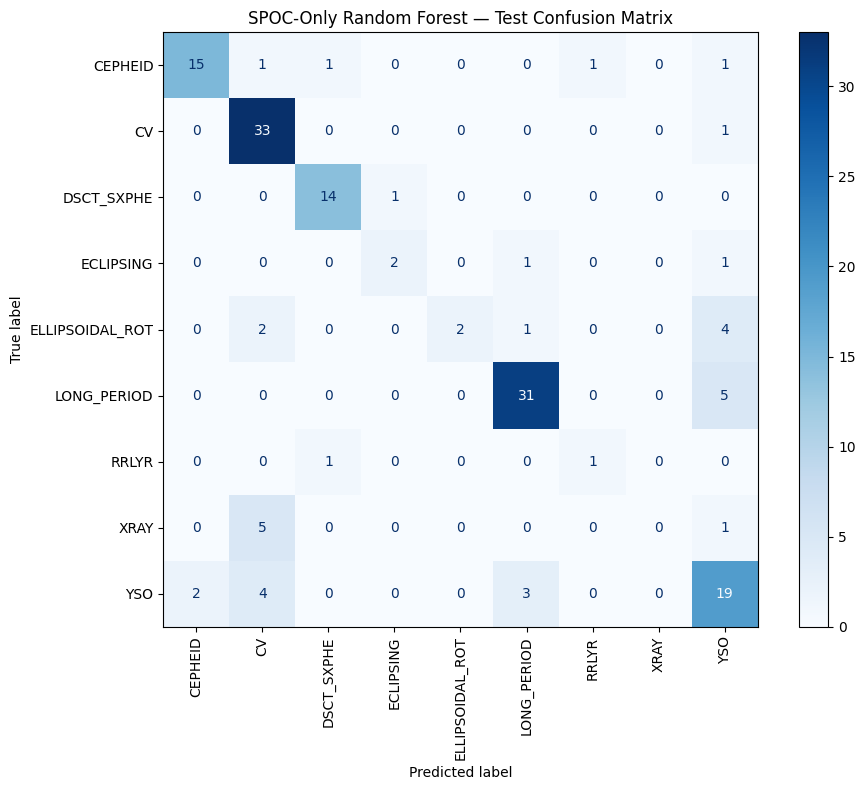

QLP-only Random Forest — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.84      0.73      0.78        70
             CV       0.00      0.00      0.00         1
     DSCT_SXPHE       0.70      0.67      0.68        63
      ECLIPSING       0.68      0.45      0.55        33
ELLIPSOIDAL_ROT       0.49      0.58      0.53        45
    LONG_PERIOD       0.71      0.92      0.80       146
          RRLYR       1.00      0.40      0.57         5
           XRAY       0.00      0.00      0.00         3
            YSO       0.78      0.35      0.48        40

       accuracy                           0.70       406
      macro avg       0.58      0.46      0.49       406
   weighted avg       0.71      0.70      0.68       406



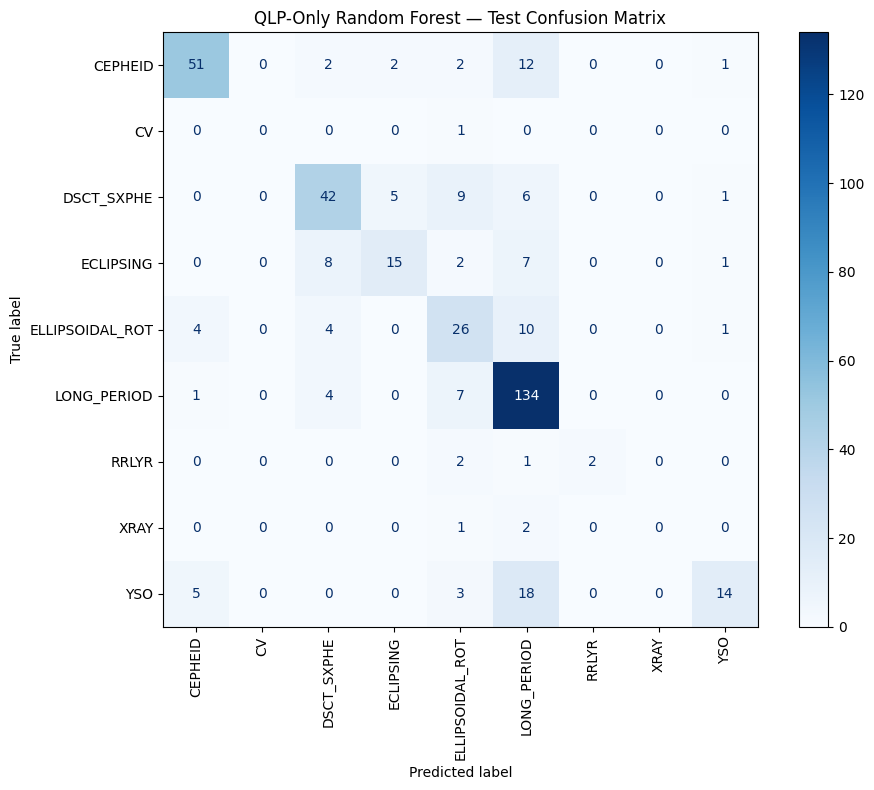

TESSCut-only Random Forest — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.26      0.29      0.28       199
             CV       0.10      0.03      0.04       120
     DSCT_SXPHE       0.21      0.20      0.20       212
      ECLIPSING       0.21      0.23      0.22       250
ELLIPSOIDAL_ROT       0.30      0.32      0.31       241
    LONG_PERIOD       0.43      0.31      0.36       106
          RRLYR       0.20      0.28      0.24       269
           XRAY       0.00      0.00      0.00         6
            YSO       0.80      0.74      0.76       223

       accuracy                           0.31      1626
      macro avg       0.28      0.27      0.27      1626
   weighted avg       0.32      0.31      0.31      1626



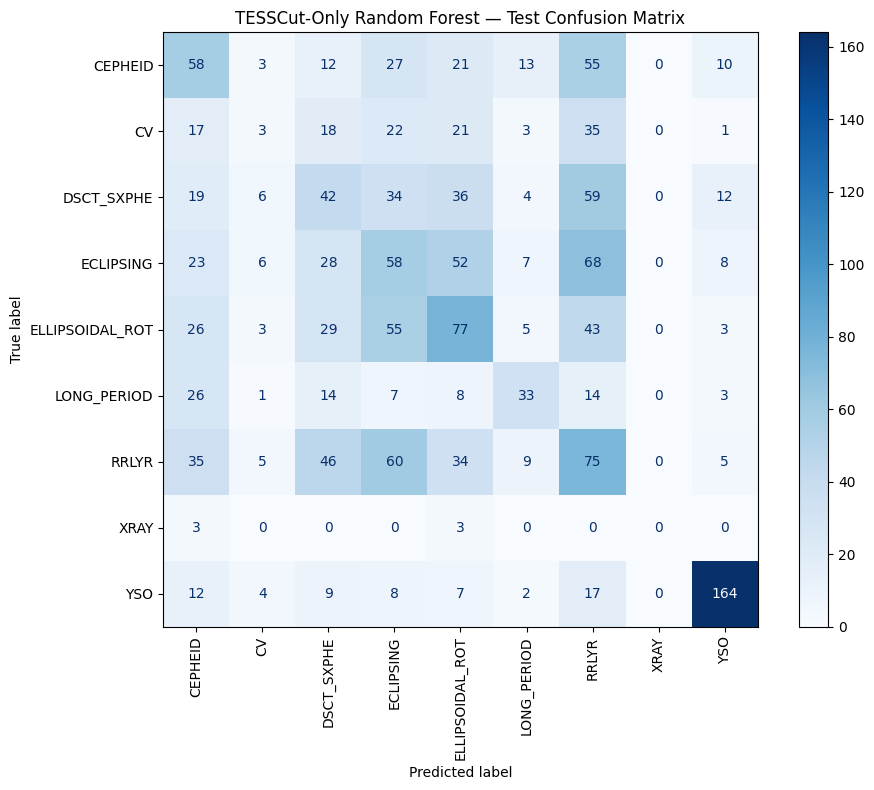

Per-family test metrics by provenance:


,Provenance,Family,Precision,Recall,F1Score,Support
0,SPOC,CEPHEID,0.882,0.789,0.833,19
1,SPOC,CV,0.733,0.971,0.835,34
2,SPOC,DSCT_SXPHE,0.875,0.933,0.903,15
3,SPOC,ECLIPSING,0.667,0.500,0.571,4
4,SPOC,ELLIPSOIDAL_ROT,1.000,0.222,0.364,9
5,SPOC,LONG_PERIOD,0.861,0.861,0.861,36
6,SPOC,RRLYR,0.500,0.500,0.500,2
7,SPOC,XRAY,0.000,0.000,0.000,6
8,SPOC,YSO,0.594,0.679,0.633,28
9,QLP,CEPHEID,0.836,0.729,0.779,70


In [28]:
# ============================================================
# Provenance-specific test confusion matrices
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ProvenanceConfusionInputs = [
    ("SPOC", SpocResults["y_test"], SpocResults["test_pred"]),
    ("QLP", QlpResults["y_test"], QlpResults["test_pred"]),
    ("TESSCut", TessCutResults["y_test"], TessCutResults["test_pred"]),
]

ProvenanceClassificationReportRows = []

for ProvenanceName, yTrueProv, yPredProv in ProvenanceConfusionInputs:
    LabelsProv = sorted(pd.Series(yTrueProv).dropna().unique())

    print(f"{ProvenanceName}-only Random Forest — test classification report:")
    print(classification_report(
        yTrueProv,
        yPredProv,
        labels=LabelsProv,
        zero_division=0,
    ))

    Fig, Ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(
        yTrueProv,
        yPredProv,
        labels=LabelsProv,
        xticks_rotation=90,
        cmap="Blues",
        values_format="d",
        ax=Ax,
    )
    Ax.set_title(f"{ProvenanceName}-Only Random Forest — Test Confusion Matrix")
    Fig.tight_layout()
    plt.show()
    plt.close(Fig)

    ReportDict = classification_report(
        yTrueProv,
        yPredProv,
        labels=LabelsProv,
        output_dict=True,
        zero_division=0,
    )

    for FamilyName in LabelsProv:
        FamilyMetrics = ReportDict.get(FamilyName, {})
        ProvenanceClassificationReportRows.append({
            "Provenance": ProvenanceName,
            "Family": FamilyName,
            "Precision": FamilyMetrics.get("precision", np.nan),
            "Recall": FamilyMetrics.get("recall", np.nan),
            "F1Score": FamilyMetrics.get("f1-score", np.nan),
            "Support": FamilyMetrics.get("support", np.nan),
        })

ProvenanceClassificationReportDf = pd.DataFrame(ProvenanceClassificationReportRows)

print("Per-family test metrics by provenance:")
display(
    ProvenanceClassificationReportDf.style.format({
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1Score": "{:.3f}",
        "Support": "{:.0f}",
    })
)

ProvenanceClassificationReportDf.to_csv(
    OutputDir / "provenance_specific_test_classification_metrics.csv",
    index=False,
)



### Feature Category Comparison

Individual feature rankings are useful, but they can be noisy because many features are correlated. A more interpretable comparison is to group features by their astrophysical meaning.

This section groups features into categories such as:

- periodicity / Lomb–Scargle structure
- phase-folded morphology
- amplitude
- flux distribution
- local variability / stochasticity
- observation quality / cadence

The goal is to compare *types of information* preserved by each provenance source rather than individual feature names alone.


In [29]:

# ============================================================
# Feature category importance comparison
# ============================================================

def categorize_feature(feature_name):
    """Map a feature name into a broad astrophysical/observational category."""
    f = str(feature_name)

    if f.startswith("Phase"):
        return "Phase-folded morphology"

    if f.startswith("Ls") or "Frequency" in f or "Period" in f or "FalseAlarm" in f:
        return "Periodicity / LS structure"

    if "Amplitude" in f:
        return "Amplitude / extrema"

    if (
        "Skewness" in f or
        "Kurtosis" in f or
        "Tail" in f or
        "P05" in f or
        "P10" in f or
        "P50" in f or
        "P90" in f or
        "P95" in f
    ):
        return "Flux distribution / shape"

    if (
        "EtaVonNeumann" in f or
        "SuccessiveDiff" in f or
        "MaxAbsSlope" in f or
        "Slope" in f or
        "Smoothness" in f
    ):
        return "Local variability / stochasticity"

    if (
        "Cadence" in f or
        "TimeSpan" in f or
        "Quality" in f or
        "Snr" in f or
        "SNR" in f or
        "LowSnr" in f
    ):
        return "Observation quality / cadence"

    if "FluxStd" in f or "Std" in f:
        return "Flux scatter / noise"

    return "Other"


CategoryRfImportanceDf = (
    ProvenanceFeatureImportanceDf
    .assign(Category=lambda df: df["Feature"].apply(categorize_feature))
    .groupby(["Provenance", "Category"], as_index=False)["RFImportance"]
    .sum()
    .sort_values(["Provenance", "RFImportance"], ascending=[True, False])
)

CategoryRfImportancePivotDf = (
    CategoryRfImportanceDf
    .pivot(index="Category", columns="Provenance", values="RFImportance")
    .fillna(0)
)

print("RF built-in importance by feature category:")
display(CategoryRfImportancePivotDf)


CategoryPermutationImportanceDf = (
    ProvenancePermutationImportanceDf
    .assign(Category=lambda df: df["Feature"].apply(categorize_feature))
    .groupby(["Provenance", "Category"], as_index=False)["PermutationImportanceMean"]
    .sum()
    .sort_values(["Provenance", "PermutationImportanceMean"], ascending=[True, False])
)

CategoryPermutationImportancePivotDf = (
    CategoryPermutationImportanceDf
    .pivot(index="Category", columns="Provenance", values="PermutationImportanceMean")
    .fillna(0)
)

print("Permutation importance by feature category:")
display(CategoryPermutationImportancePivotDf)


ProvenanceFeatureImportanceDf.to_csv(OutputDir / "provenance_rf_feature_importance.csv", index=False)
ProvenancePermutationImportanceDf.to_csv(OutputDir / "provenance_permutation_importance.csv", index=False)
CategoryRfImportancePivotDf.to_csv(OutputDir / "provenance_rf_feature_category_importance.csv")
CategoryPermutationImportancePivotDf.to_csv(OutputDir / "provenance_permutation_feature_category_importance.csv")

print("Saved provenance feature-importance comparison outputs to:")
print(OutputDir)


RF built-in importance by feature category:


Provenance,QLP,SPOC,TESSCut
Category,,,
Amplitude / extrema,0.033884,0.036526,0.052754
Flux distribution / shape,0.183261,0.143491,0.156173
Flux scatter / noise,0.061305,0.111531,0.073238
Local variability / stochasticity,0.055912,0.096052,0.092000
Observation quality / cadence,0.030747,0.041508,0.054072
Other,0.048108,0.053207,0.042197
Periodicity / LS structure,0.276734,0.253915,0.212587
Phase-folded morphology,0.310050,0.263771,0.316979


Permutation importance by feature category:


Provenance,QLP,SPOC,TESSCut
Category,,,
Amplitude / extrema,0.014077,-0.008377,-0.001455
Flux distribution / shape,0.031469,-0.016042,0.004648
Flux scatter / noise,0.021796,0.049884,-0.000067
Local variability / stochasticity,0.026198,-0.025005,0.005426
Observation quality / cadence,0.005683,0.000153,0.002696
Other,0.027192,-0.014567,0.005381
Periodicity / LS structure,0.104784,0.122423,-0.010994
Phase-folded morphology,0.039568,-0.080751,-0.018164


Saved provenance feature-importance comparison outputs to:
/data/projects/TESS-research/ml_analytics/output



### Provenance-Specific Feature Importance Interpretation

This analysis should be interpreted together with the provenance-specific accuracy results.

If the top features and feature-category totals differ substantially across SPOC, QLP, and TESSCut models, that supports the idea that provenance does not merely change overall noise level. Instead, different preprocessing and extraction pipelines may change which categories of astrophysical information remain recoverable.

A scientifically meaningful pattern would be:

| Provenance Pattern | Interpretation |
|---|---|
| SPOC relies more on periodic / harmonic features | cleaner pipeline products preserve detailed periodic structure |
| QLP relies on mixed periodic and statistical features | intermediate preprocessing preserves some periodic information but less consistently |
| TESSCut relies more on amplitude, slope, cadence, or flux-distribution features | cutout-based light curves may retain coarse variability but weaken fine harmonic separability |
| Phase-folded morphology features rank highly across models | folded light-curve shape contains real astrophysical information |
| Observation-quality features rank highly | model performance is partly limited by data quality and sampling effects |

Important caution: provenance-specific datasets differ not only in preprocessing pipeline, but also in sample size and class distribution. Therefore, feature-importance differences should be interpreted as evidence of **provenance-associated information shifts**, not as a perfectly isolated causal effect of the pipeline alone.

Overall, this section helps connect the machine-learning results to the central astrophysical question:

> How do different TESS light-curve provenance sources affect the recoverability of variable-star signatures?


## Step 20 — Provenance-Specific Feature Importance Interpretation and SPOC Diagnostic Follow-Up

### Confirmation of Provenance-Specific Feature-Importance Result

The **Step 19** provenance-specific analysis continues to support one of the central conclusions of the project:

> The observed SPOC, QLP, and TESSCut subsets show substantially different Random Forest feature-importance patterns and substantially different held-out classification performance.

Current provenance-specific test results are:

| Provenance | Test Accuracy | Test Balanced Accuracy |
|---|---:|---:|
| SPOC | 0.720 | 0.521 |
| QLP | 0.719 | 0.479 |
| TESSCut | 0.344 | 0.293 |

The feature rankings also differ. In the built-in Random Forest importance:

- **SPOC** is led by `OriginalFluxStd` and Lomb–Scargle periods (`LsPeriod3`, `LsBestPeriod`, `LsPeriod2`), followed by local-variability descriptors.
- **QLP** is led by Lomb–Scargle periods and `TailRatio`, with phase morphology and flux-scatter features also contributing.
- **TESSCut** is led by `EtaVonNeumann`, `FluxAmplitude`, `TimeSpanDays`, `CadenceCount`, and `MaxAbsSlope`, with detailed LS features less dominant near the top.

Permutation importance gives a somewhat different but still provenance-dependent picture:

- **SPOC:** `OriginalFluxStd` is clearly dominant; many other permutation effects are small or unstable, which is expected given the much smaller SPOC sample.
- **QLP:** phase morphology, `OriginalFluxStd`, `TimeSpanDays`, local variability, and LS features all contribute.
- **TESSCut:** tail/flux-shape, cadence/time-span, local variability, phase morphology, and selected LS features contribute.

Because built-in and permutation importance respond differently to correlated predictors, the strongest conclusion is about the **overall pattern**, not any single ranked feature.

### Scientific Interpretation

The current results are consistent with provenance-associated shifts in the information available to the classifier:

| Provenance | Current dominant pattern |
|---|---|
| SPOC | flux scatter plus strong LS-period structure |
| QLP | mixed periodic, phase-morphology, flux-shape, and variability information |
| TESSCut | stronger reliance on cadence/time-span, amplitude, local variability, and broad flux-shape information |

This supports the project’s broader interpretation:

> Different light-curve provenance subsets are associated with different recoverable variability signatures and different Random Forest decision structures.

### Important Caution

This full-dataset provenance comparison is **not a perfectly controlled causal experiment**. The subsets also differ in sample size and family composition. Therefore, the most defensible current claim is:

> The observed provenance-specific datasets exhibit substantially different feature-importance patterns, consistent with the interpretation that different TESS light-curve products preserve different categories of recoverable astrophysical variability information.

The planned matched SPOC–TESSCut and QLP–TESSCut experiments are important because they will reduce sample-composition confounding and provide the cleaner apples-to-apples test.

### SPOC `OriginalFluxStd` / `OriginalFluxSnr` Follow-Up

`OriginalFluxStd` is the highest built-in and permutation-importance feature in the current SPOC-only model.

`OriginalFluxSnr`, however, is **not part of the final model feature set**: Step 4 removes it because its absolute Spearman correlation with `OriginalFluxStd` is approximately **0.965**. The diagnostic below still examines both upstream variables to understand why they are so tightly related, but only `OriginalFluxStd` remains in the trained Random Forest.


In [30]:

# ============================================================
# Step 19 Diagnostic: OriginalFluxStd and OriginalFluxSnr in SPOC
# ============================================================

DiagnosticFeatures = [
    col for col in ["OriginalFluxStd", "OriginalFluxSnr"]
    if col in globals().get("ProvenanceComparisonDfForTraining", ModelDf).columns
]

if len(DiagnosticFeatures) == 0:
    raise KeyError(
        "Neither OriginalFluxStd nor OriginalFluxSnr exists in the current dataframe."
    )

# Use the final dataframe from Step 18 if available; otherwise fall back to ModelDf.
DiagnosticBaseDf = globals().get("ProvenanceComparisonDfForTraining", ModelDf).copy()

# Identify provenance column robustly.
PossibleProvenanceColumns = ["Provenance", "provenance", "Source", "source"]
DiagnosticProvenanceColumn = None

for CandidateColumn in PossibleProvenanceColumns:
    if CandidateColumn in DiagnosticBaseDf.columns:
        DiagnosticProvenanceColumn = CandidateColumn
        break

if DiagnosticProvenanceColumn is None:
    raise KeyError(
        "Could not find provenance/source column. "
        f"Tried: {PossibleProvenanceColumns}"
    )

SpocDiagnosticDf = DiagnosticBaseDf[
    DiagnosticBaseDf[DiagnosticProvenanceColumn] == "SPOC"
].copy()

print(f"SPOC diagnostic row count: {len(SpocDiagnosticDf)}")
print(f"Using provenance column: {DiagnosticProvenanceColumn}")
print(f"Diagnostic features available: {DiagnosticFeatures}")


# ------------------------------------------------------------
# 1. Distribution of OriginalFluxStd / OriginalFluxSnr by class
# ------------------------------------------------------------

SpocFeatureByClassDf = (
    SpocDiagnosticDf
    .groupby(TargetColumn)[DiagnosticFeatures]
    .agg(["count", "mean", "median", "std"])
)

print("OriginalFluxStd / OriginalFluxSnr by class within SPOC:")
display(SpocFeatureByClassDf)


# ------------------------------------------------------------
# 2. Correct-vs-incorrect diagnostic if SPOC model variables exist
# ------------------------------------------------------------

RequiredSpocObjects = ["SpocRfModel", "XSpocTest", "YSpocTest"]
MissingSpocObjects = [name for name in RequiredSpocObjects if name not in globals()]

if MissingSpocObjects:
    print(
        "Skipping correct-vs-incorrect SPOC prediction diagnostic because "
        f"these objects are missing: {MissingSpocObjects}"
    )
else:
    SpocTestPredictionDf = XSpocTest.copy()
    SpocTestPredictionDf[TargetColumn] = YSpocTest
    SpocTestPredictionDf["Prediction"] = SpocRfModel.predict(XSpocTest)
    SpocTestPredictionDf["Correct"] = (
        SpocTestPredictionDf[TargetColumn] == SpocTestPredictionDf["Prediction"]
    )

    CorrectComparisonFeatures = [
        col for col in DiagnosticFeatures
        if col in SpocTestPredictionDf.columns
    ]

    if CorrectComparisonFeatures:
        SpocCorrectVsIncorrectDf = (
            SpocTestPredictionDf
            .groupby("Correct")[CorrectComparisonFeatures]
            .agg(["count", "mean", "median", "std"])
        )

        print("SPOC test set: OriginalFluxStd / OriginalFluxSnr for correct vs incorrect predictions:")
        display(SpocCorrectVsIncorrectDf)
    else:
        print("Diagnostic features are not present in XSpocTest; skipping correct-vs-incorrect comparison.")


# ------------------------------------------------------------
# 3. Correlation with related amplitude / quality / variability features
# ------------------------------------------------------------

CandidateCorrelationFeatures = [
    "OriginalFluxStd",
    "OriginalFluxSnr",
    "FluxAmplitude",
    "FluxPercentAmplitude95To5",
    "PhaseAmplitude95To5",
    "EtaVonNeumann",
    "MedianAbsSuccessiveDiff",
    "LsMaxPower",
    "LsFalseAlarmProbability",
    "CadenceCount",
    "TimeSpanDays",
]

AvailableCorrelationFeatures = [
    col for col in CandidateCorrelationFeatures
    if col in SpocDiagnosticDf.columns
]

if len(AvailableCorrelationFeatures) >= 2:
    SpocCorrelationDf = SpocDiagnosticDf[AvailableCorrelationFeatures].corr(
        method="spearman"
    )

    print("Spearman correlation among SPOC diagnostic / variability / quality features:")
    display(SpocCorrelationDf)

    ImportantCorrelationRows = [
        col for col in ["OriginalFluxStd", "OriginalFluxSnr"]
        if col in SpocCorrelationDf.index
    ]

    if ImportantCorrelationRows:
        print("Correlations involving OriginalFluxStd / OriginalFluxSnr:")
        display(
            SpocCorrelationDf
            .loc[ImportantCorrelationRows]
            .T
            .sort_values(ImportantCorrelationRows[0], ascending=False)
        )
else:
    print("Not enough related features available for correlation analysis.")


# ------------------------------------------------------------
# 4. Class-level median diagnostic features and sample counts
# ------------------------------------------------------------

SpocClassSupportDf = (
    SpocDiagnosticDf[TargetColumn]
    .value_counts()
    .rename_axis(TargetColumn)
    .reset_index(name="SpocSampleCount")
)

SpocClassFeatureSummaryDf = (
    SpocDiagnosticDf
    .groupby(TargetColumn)[DiagnosticFeatures]
    .median()
    .reset_index()
    .merge(SpocClassSupportDf, on=TargetColumn, how="left")
    .sort_values("SpocSampleCount", ascending=False)
)

print("SPOC class-level median diagnostic features and sample count:")
display(SpocClassFeatureSummaryDf)


SPOC diagnostic row count: 509
Using provenance column: Provenance
Diagnostic features available: ['OriginalFluxStd', 'OriginalFluxSnr']
OriginalFluxStd / OriginalFluxSnr by class within SPOC:


OriginalFluxStd                                    OriginalFluxSnr                                    
                          count        mean    median          std           count        mean      median         std
family                                                                                                                
CEPHEID                      64    0.160111  0.115152     0.137338              64    9.372311    8.684484    5.681071
CV                          114    2.540550  1.042355     3.354267             114    2.714477    0.959382    6.603575
DSCT_SXPHE                   51    9.668307  0.004345    68.892891              51  367.758739  230.141286  451.123337
ECLIPSING                    14    0.058100  0.050688     0.031964              14   26.953484   19.766606   25.090322
ELLIPSOIDAL_ROT              29    0.016846  0.007028     0.024907              29  230.632152  142.290168  245.157974
LONG_PERIOD                 118  134.731638  0.006865  1463.456553             118  269.748308  145.669910  323.780232
RRLYR                         5    0.139091  0.104370     0.061278               5    8.233980    9.581260    3.010721
XRAY                         20    1.384162  0.119527     2.213825              20  212.366208   15.009396  587.537013
YSO                          94    0.154511  0.069745     0.299179              94   44.434194   14.340045   84.238184

SPOC test set: OriginalFluxStd / OriginalFluxSnr for correct vs incorrect predictions:


OriginalFluxStd                              
                  count      mean    median       std
Correct                                              
False                36  0.701053  0.066894  1.658640
True                117  1.008870  0.063227  2.407589

Spearman correlation among SPOC diagnostic / variability / quality features:


,OriginalFluxStd,OriginalFluxSnr,FluxAmplitude,FluxPercentAmplitude95To5,PhaseAmplitude95To5,EtaVonNeumann,MedianAbsSuccessiveDiff,LsMaxPower,LsFalseAlarmProbability,CadenceCount,TimeSpanDays
OriginalFluxStd,1.000000,-0.987397,0.018630,0.030878,-0.347776,0.341719,0.370550,-0.263734,0.396766,-0.115231,-0.339954
OriginalFluxSnr,-0.987397,1.000000,-0.029672,-0.033179,0.349522,-0.352724,-0.379196,0.271988,-0.402971,0.102589,0.327790
FluxAmplitude,0.018630,-0.029672,1.000000,-0.099970,-0.475053,0.577105,0.450479,-0.644727,0.206970,0.452189,0.270614
FluxPercentAmplitude95To5,0.030878,-0.033179,-0.099970,1.000000,-0.101558,0.124801,0.144506,-0.207791,0.172886,-0.007282,-0.007078
PhaseAmplitude95To5,-0.347776,0.349522,-0.475053,-0.101558,1.000000,-0.735410,-0.749734,0.794988,-0.674753,-0.111737,0.111574
EtaVonNeumann,0.341719,-0.352724,0.577105,0.124801,-0.735410,1.000000,0.932520,-0.777819,0.665433,0.069049,-0.160467
MedianAbsSuccessiveDiff,0.370550,-0.379196,0.450479,0.144506,-0.749734,0.932520,1.000000,-0.716935,0.667613,-0.084224,-0.301406
LsMaxPower,-0.263734,0.271988,-0.644727,-0.207791,0.794988,-0.777819,-0.716935,1.000000,-0.710134,-0.177281,0.007002
LsFalseAlarmProbability,0.396766,-0.402971,0.206970,0.172886,-0.674753,0.665433,0.667613,-0.710134,1.000000,-0.195916,-0.229179
CadenceCount,-0.115231,0.102589,0.452189,-0.007282,-0.111737,0.069049,-0.084224,-0.177281,-0.195916,1.000000,0.678793


Correlations involving OriginalFluxStd / OriginalFluxSnr:


,OriginalFluxStd,OriginalFluxSnr
OriginalFluxStd,1.000000,-0.987397
LsFalseAlarmProbability,0.396766,-0.402971
MedianAbsSuccessiveDiff,0.370550,-0.379196
EtaVonNeumann,0.341719,-0.352724
FluxPercentAmplitude95To5,0.030878,-0.033179
FluxAmplitude,0.018630,-0.029672
CadenceCount,-0.115231,0.102589
LsMaxPower,-0.263734,0.271988
TimeSpanDays,-0.339954,0.327790
PhaseAmplitude95To5,-0.347776,0.349522


SPOC class-level median diagnostic features and sample count:


,family,OriginalFluxStd,OriginalFluxSnr,SpocSampleCount
5,LONG_PERIOD,0.006865,145.669910,118
1,CV,1.042355,0.959382,114
8,YSO,0.069745,14.340045,94
0,CEPHEID,0.115152,8.684484,64
2,DSCT_SXPHE,0.004345,230.141286,51
4,ELLIPSOIDAL_ROT,0.007028,142.290168,29
7,XRAY,0.119527,15.009396,20
3,ECLIPSING,0.050688,19.766606,14
6,RRLYR,0.104370,9.581260,5


### Interpretation Guide for the SPOC `OriginalFluxStd` / `OriginalFluxSnr` Diagnostic

This diagnostic examines the relationship between two upstream quantities, but only `OriginalFluxStd` remains in the final Random Forest feature set. `OriginalFluxSnr` was removed in Step 4 because of its near-duplicate Spearman relationship with `OriginalFluxStd`.

Use the diagnostic outputs as follows:

- If the two quantities differ strongly by variable-star family, the underlying flux-scatter / relative-signal concept may carry astrophysical information.
- If `OriginalFluxStd` differs between correct and incorrect predictions, it may help identify cases that are easier or harder to classify.
- Correlations with amplitude or local-variability features indicate overlap with astrophysical variability strength.
- Correlations with cadence or quality measures indicate an observational/sampling contribution.

The scientifically careful interpretation is that `OriginalFluxStd` is an informative variability/scatter descriptor in the SPOC subset, while `OriginalFluxSnr` is useful here primarily for understanding that descriptor's upstream mathematical relationship—not as a separate model predictor.



### Update: Origin of `OriginalFluxStd` and `OriginalFluxSnr`

The high importance of `OriginalFluxStd` and `OriginalFluxSnr` in the SPOC-only model motivated a follow-up check of the upstream feature-generation logic.

The origin of these fields was traced to `tess_variable_star_categorization.ipynb`, where the relevant quantities are computed as:

```python
medianFlux = float(np.nanmedian(validFlux))
stdFlux = float(np.nanstd(validFlux))

fluxSnr = None if lowStd else float(abs(medianFlux) / stdFlux)
```

Therefore:

```text
fluxSnr = abs(fluxMedian) / fluxStd
```

This explains why `OriginalFluxStd` and `OriginalFluxSnr` show an almost perfect Spearman anti-correlation.

They are not independent features. Instead, `OriginalFluxSnr` is mathematically derived from `fluxStd` and the median flux level. If the median flux is relatively stable or normalized across a subset of light curves, then increasing `fluxStd` will almost automatically decrease `fluxSnr`.

---

### Revised Interpretation

The earlier diagnostic showed that `OriginalFluxStd` and `OriginalFluxSnr` vary substantially across variable-star families. In the current model, `OriginalFluxStd` remains a predictor, while `OriginalFluxSnr` is removed by the Step 4 correlation filter. However, because `OriginalFluxSnr` is derived from `OriginalFluxStd`, they should not be interpreted as two independent astrophysical discoveries.

A more careful interpretation is:

> `OriginalFluxStd` and `OriginalFluxSnr` form a linked variability / signal-quality descriptor group. Their high feature importance in the SPOC-only model likely reflects the importance of flux scatter relative to baseline signal level, rather than two independent physical measurements.

This does not invalidate the SPOC feature-importance result. Instead, it clarifies that the model is strongly using a single underlying concept:

```text
relative flux scatter / variability strength
```

rather than two unrelated quantities.

---

### Scientific Meaning

In well-processed SPOC light curves, relative flux scatter can still be astrophysically meaningful because different variable-star families naturally exhibit different variability amplitudes, smoothness, and scatter properties.

However, because this descriptor also depends on measurement noise and preprocessing, it should be described cautiously as a combined astrophysical-and-observational feature.

The safest wording for the paper/notebook is:

> The SPOC-only model assigns high importance to `OriginalFluxStd`. The upstream `OriginalFluxSnr` quantity is mathematically linked through `abs(fluxMedian) / fluxStd` and is removed before modeling because of near-duplicate correlation. Together, the diagnostic suggests that relative flux scatter is an important discriminative concept in the SPOC subset, likely combining intrinsic variability strength with observational noise behavior.

---

### Implication for Feature Importance Analysis

Because `OriginalFluxStd` and `OriginalFluxSnr` are highly redundant, future feature-importance interpretation should avoid double-counting them.

For scientific discussion, they should be grouped under a single category such as:

```text
Flux scatter / relative signal strength
```

rather than discussed separately.

This reinforces the broader conclusion that feature importance must be interpreted with awareness of feature definitions and correlations, not only model rankings.


### Final Update: Effect of `OriginalFluxStd` / `OriginalFluxSnr` Redundancy on the Provenance Conclusion

The relationship

```text
fluxSnr = abs(fluxMedian) / fluxStd
```

explains why `OriginalFluxStd` and `OriginalFluxSnr` are tightly anti-correlated. The current Step 4 correlation filter removes `OriginalFluxSnr` (`|Spearman ρ| ≈ 0.965`) and retains `OriginalFluxStd`.

Therefore, the current provenance-specific Random Forest does **not** double-count these two quantities as separate model inputs.

### Revised SPOC Interpretation

The correct current statement is:

> The SPOC-only model assigns especially high importance to `OriginalFluxStd`, together with Lomb–Scargle period structure and local-variability features. The related upstream `OriginalFluxSnr` quantity is excluded from the final model because of near-duplicate correlation.

### Does This Affect the Provenance Feature-Importance Conclusion?

No. The main conclusion remains supported.

The current provenance-specific models show large performance differences and different feature-importance structures:

- SPOC emphasizes `OriginalFluxStd` and LS-period features.
- QLP shows a mixed periodic, morphology, flux-shape, and variability pattern.
- TESSCut relies relatively more on cadence/time-span, amplitude, local variability, and broad flux-shape descriptors.

The exact ranking depends on whether built-in or permutation importance is used, especially for correlated features and the relatively small SPOC subset. The robust result is the **difference in overall feature-importance pattern across provenance**, not the ranking of one individual feature.

### Final Provenance Feature-Importance Claim

> The observed provenance-specific datasets exhibit substantially different feature-importance patterns. These differences are consistent with the interpretation that different TESS light-curve products preserve different categories of recoverable astrophysical variability information.

This wording remains strong but appropriately cautious because sample size, family composition, observational availability, and preprocessing differ between the current provenance subsets. The matched SPOC–TESSCut and QLP–TESSCut analyses are the next step for isolating provenance more cleanly.


In [31]:

# ============================================================
# Step 20.1 — Spearman Correlation of Provenance-Specific
#              Random Forest Feature Importance
# ============================================================
#
# Goal:
# Quantify how similarly the SPOC-only, QLP-only, and TESSCut-only
# Random Forest models rank the same features.
#
# Spearman correlation is appropriate because the scientific question is
# primarily about feature-ranking agreement rather than absolute importance
# magnitudes.
#
# This uses the RF built-in feature-importance table created in Step 19:
#     ProvenanceFeatureImportanceDf
#
# No models are retrained here.

RequiredColumns = {"Provenance", "Feature", "RFImportance"}

if "ProvenanceFeatureImportanceDf" not in globals():
    raise NameError(
        "ProvenanceFeatureImportanceDf is not available. "
        "Run the provenance-specific feature-importance analysis in Step 19 first."
    )

MissingColumns = RequiredColumns - set(ProvenanceFeatureImportanceDf.columns)
if MissingColumns:
    raise KeyError(
        "ProvenanceFeatureImportanceDf is missing required columns: "
        f"{sorted(MissingColumns)}"
    )

# Put each provenance-specific importance vector in one column,
# aligned by feature name.
ProvenanceImportanceWideDf = (
    ProvenanceFeatureImportanceDf
    .pivot_table(
        index="Feature",
        columns="Provenance",
        values="RFImportance",
        aggfunc="first"
    )
)

ExpectedProvenances = ["SPOC", "QLP", "TESSCut"]
AvailableProvenances = [
    ProvenanceName
    for ProvenanceName in ExpectedProvenances
    if ProvenanceName in ProvenanceImportanceWideDf.columns
]

if len(AvailableProvenances) < 2:
    raise ValueError(
        "At least two provenance-specific importance vectors are required. "
        f"Available provenance columns: {list(ProvenanceImportanceWideDf.columns)}"
    )

# Restrict comparison to features present for every provenance being compared.
CommonFeatureImportanceDf = (
    ProvenanceImportanceWideDf[AvailableProvenances]
    .dropna(axis=0, how="any")
)

print(
    "Number of common features used for provenance feature-importance "
    f"rank correlation: {len(CommonFeatureImportanceDf)}"
)

# Spearman rank-correlation matrix.
ProvenanceFeatureImportanceSpearmanDf = (
    CommonFeatureImportanceDf
    .corr(method="spearman")
)

print(
    "Spearman rank correlation of RF built-in feature importance "
    "across provenance-specific models:"
)
display(ProvenanceFeatureImportanceSpearmanDf)

# Also provide the three unique pairwise correlations in a compact table.
PairwiseRows = []
for i, ProvenanceA in enumerate(AvailableProvenances):
    for ProvenanceB in AvailableProvenances[i + 1:]:
        PairwiseRows.append({
            "ProvenanceA": ProvenanceA,
            "ProvenanceB": ProvenanceB,
            "SpearmanRho": ProvenanceFeatureImportanceSpearmanDf.loc[
                ProvenanceA, ProvenanceB
            ],
            "CommonFeatureCount": len(CommonFeatureImportanceDf),
        })

ProvenanceFeatureImportanceSpearmanPairsDf = pd.DataFrame(PairwiseRows)

print("Unique provenance-pair Spearman correlations:")
display(ProvenanceFeatureImportanceSpearmanPairsDf)

# Save for paper/report use.
if "OutputDir" in globals():
    ProvenanceFeatureImportanceSpearmanDf.to_csv(
        OutputDir / "provenance_rf_feature_importance_spearman_matrix.csv"
    )
    ProvenanceFeatureImportanceSpearmanPairsDf.to_csv(
        OutputDir / "provenance_rf_feature_importance_spearman_pairs.csv",
        index=False
    )


Number of common features used for provenance feature-importance rank correlation: 52
Spearman rank correlation of RF built-in feature importance across provenance-specific models:


Provenance,SPOC,QLP,TESSCut
Provenance,,,
SPOC,1.000000,0.677951,0.535454
QLP,0.677951,1.000000,0.321153
TESSCut,0.535454,0.321153,1.000000


Unique provenance-pair Spearman correlations:


,ProvenanceA,ProvenanceB,SpearmanRho,CommonFeatureCount
0,SPOC,QLP,0.677951,52
1,SPOC,TESSCut,0.535454,52
2,QLP,TESSCut,0.321153,52


## Step 21 — Matched SPOC vs TESSCut Random Forest Comparison

### Goal

Perform an apples-to-apples provenance comparison using only stars that have both a SPOC and a corresponding TESSCut feature row.

Input:

```text
/data/projects/TESS-research/data_pipeline/SPOC_TESSCutCache/SPOC_TESSCut_features_QC.parquet
```

The comparison is controlled at the `VSXId` level:

- exactly one SPOC row and one TESSCut row are retained per matched `VSXId`;
- the family label must agree between the two rows;
- a single stratified train/test split is created from the matched `VSXId` list;
- the **same train and test stars** are used for both RF models;
- the same feature columns, imputation strategy, RF hyperparameters, and importance methods are used.

This removes the principal sample-composition difference present in the earlier full-dataset provenance comparison and isolates provenance much more cleanly.

The outputs include:

- train/test accuracy and balanced accuracy;
- per-family classification metrics;
- RF built-in feature importance;
- permutation importance on balanced accuracy;
- feature-importance rank comparison and Spearman rank correlation.


In [32]:
# ============================================================
# Shared helper for matched official-product vs TESSCut RF comparisons
# ============================================================

from scipy.stats import spearmanr

SPOC_TESSCUT_COMPARISON_OUTPUT_QC = (
    "/data/projects/TESS-research/data_pipeline/"
    "SPOC_TESSCutCache/SPOC_TESSCut_features_QC.parquet"
)

QLP_TESSCUT_COMPARISON_OUTPUT_QC = (
    "/data/projects/TESS-research/data_pipeline/"
    "QLP_TESSCutCache/QLP_TESSCut_features_QC.parquet"
)


def _resolve_comparison_provenance_column(df):
    for col in ["Provenance", "provenance", "Source", "source"]:
        if col in df.columns:
            return col
    raise KeyError(
        "Could not find a provenance/source column in matched comparison feature table."
    )


def _prepare_matched_pair_dataframe(
    feature_file,
    official_provenance,
    target_column,
):
    """Validate and return exactly one official and one TESSCut row per matched VSXId."""
    df = pd.read_parquet(feature_file).copy()

    if "VSXId" not in df.columns:
        raise KeyError("Matched comparison feature table is missing VSXId.")
    if target_column not in df.columns:
        raise KeyError(f"Matched comparison feature table is missing {target_column}.")

    provenance_col = _resolve_comparison_provenance_column(df)
    df["_ProvenanceNormalized"] = df[provenance_col].map(normalize_provenance_label)

    wanted = {official_provenance, "TESSCut"}
    df = df[df["_ProvenanceNormalized"].isin(wanted)].copy()
    df["VSXId"] = df["VSXId"].astype(str)

    pair_counts = (
        df.groupby(["VSXId", "_ProvenanceNormalized"])
        .size()
        .unstack(fill_value=0)
    )

    for required_col in [official_provenance, "TESSCut"]:
        if required_col not in pair_counts.columns:
            pair_counts[required_col] = 0

    valid_ids = pair_counts.index[
        (pair_counts[official_provenance] == 1)
        & (pair_counts["TESSCut"] == 1)
    ]

    matched = df[df["VSXId"].isin(valid_ids)].copy()

    official_df = (
        matched[matched["_ProvenanceNormalized"] == official_provenance]
        .set_index("VSXId", drop=False)
        .sort_index()
    )
    tesscut_df = (
        matched[matched["_ProvenanceNormalized"] == "TESSCut"]
        .set_index("VSXId", drop=False)
        .sort_index()
    )

    common_ids = official_df.index.intersection(tesscut_df.index)
    official_df = official_df.loc[common_ids].copy()
    tesscut_df = tesscut_df.loc[common_ids].copy()

    family_mismatch = (
        official_df[target_column].astype(str)
        != tesscut_df[target_column].astype(str)
    )
    if family_mismatch.any():
        bad_ids = official_df.index[family_mismatch].tolist()
        raise ValueError(
            f"{official_provenance} vs TESSCut has family-label mismatches for "
            f"{len(bad_ids)} matched VSXIds; examples: {bad_ids[:10]}"
        )

    return official_df, tesscut_df, provenance_col


def _train_matched_rf(
    source_df,
    feature_columns,
    target_column,
    train_ids,
    test_ids,
    provenance_name,
    random_state=42,
):
    """Train RF using a preassigned VSXId split shared across provenance products."""
    train_df = source_df.loc[train_ids].copy()
    test_df = source_df.loc[test_ids].copy()

    x_train = train_df[feature_columns]
    y_train = train_df[target_column]
    x_test = test_df[feature_columns]
    y_test = test_df[target_column]

    model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=random_state,
            )),
        ]
    )

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    performance = pd.DataFrame([
        {
            "Provenance": provenance_name,
            "split": "train",
            "accuracy": accuracy_score(y_train, train_pred),
            "balanced_accuracy": balanced_accuracy_score(y_train, train_pred),
            "sample_count": len(y_train),
        },
        {
            "Provenance": provenance_name,
            "split": "test",
            "accuracy": accuracy_score(y_test, test_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
            "sample_count": len(y_test),
        },
    ])

    return {
        "model": model,
        "x_train": x_train,
        "x_test": x_test,
        "y_train": y_train,
        "y_test": y_test,
        "test_pred": test_pred,
        "performance": performance,
    }


def run_matched_provenance_comparison(
    feature_file,
    official_provenance,
    feature_columns,
    target_column,
    output_prefix,
    random_state=42,
    test_size=0.30,
):
    """
    Run a controlled official-product vs TESSCut comparison using identical VSXIds
    in train and test for both provenance-specific Random Forest models.
    """
    official_df, tesscut_df, provenance_col = _prepare_matched_pair_dataframe(
        feature_file=feature_file,
        official_provenance=official_provenance,
        target_column=target_column,
    )

    common_ids = official_df.index.to_numpy()
    pair_labels = official_df.loc[common_ids, target_column]

    class_counts = pair_labels.value_counts()
    keep_classes = class_counts[class_counts >= 2].index
    dropped_classes = class_counts[class_counts < 2]

    if len(dropped_classes) > 0:
        print(
            f"{official_provenance} vs TESSCut: dropping classes with fewer than "
            "2 matched VSXIds before stratified split:"
        )
        display(dropped_classes)

    keep_ids = official_df.index[
        official_df[target_column].isin(keep_classes)
    ].to_numpy()

    official_df = official_df.loc[keep_ids].copy()
    tesscut_df = tesscut_df.loc[keep_ids].copy()

    id_labels = official_df.loc[keep_ids, target_column]

    train_ids, test_ids = train_test_split(
        keep_ids,
        test_size=test_size,
        stratify=id_labels,
        random_state=random_state,
    )

    # Preserve deterministic ordering for easy cross-checking.
    train_ids = sorted(train_ids)
    test_ids = sorted(test_ids)

    # Use the notebook's existing reduced FeatureColumns set.
    missing_official = sorted(set(feature_columns) - set(official_df.columns))
    missing_tesscut = sorted(set(feature_columns) - set(tesscut_df.columns))
    if missing_official or missing_tesscut:
        raise ValueError(
            "Matched comparison feature schema is incompatible with current "
            f"FeatureColumns. Missing official={missing_official}; "
            f"missing TESSCut={missing_tesscut}"
        )

    official_results = _train_matched_rf(
        source_df=official_df,
        feature_columns=feature_columns,
        target_column=target_column,
        train_ids=train_ids,
        test_ids=test_ids,
        provenance_name=official_provenance,
        random_state=random_state,
    )

    tesscut_results = _train_matched_rf(
        source_df=tesscut_df,
        feature_columns=feature_columns,
        target_column=target_column,
        train_ids=train_ids,
        test_ids=test_ids,
        provenance_name="TESSCut",
        random_state=random_state,
    )

    performance_df = pd.concat(
        [official_results["performance"], tesscut_results["performance"]],
        ignore_index=True,
    )

    official_rf_imp = build_rf_feature_importance_df(
        official_results["model"],
        feature_columns,
        official_provenance,
    )
    tesscut_rf_imp = build_rf_feature_importance_df(
        tesscut_results["model"],
        feature_columns,
        "TESSCut",
    )

    official_perm_imp = build_permutation_importance_df(
        official_results["model"],
        official_results["x_test"],
        official_results["y_test"],
        feature_columns,
        official_provenance,
        scoring="balanced_accuracy",
        n_repeats=10,
        random_state=random_state,
    )
    tesscut_perm_imp = build_permutation_importance_df(
        tesscut_results["model"],
        tesscut_results["x_test"],
        tesscut_results["y_test"],
        feature_columns,
        "TESSCut",
        scoring="balanced_accuracy",
        n_repeats=10,
        random_state=random_state,
    )

    rf_rank = (
        official_rf_imp[["Feature", "RFImportance"]]
        .rename(columns={"RFImportance": f"{official_provenance}RFImportance"})
        .merge(
            tesscut_rf_imp[["Feature", "RFImportance"]]
            .rename(columns={"RFImportance": "TESSCutRFImportance"}),
            on="Feature",
            how="inner",
        )
    )
    rf_rank[f"{official_provenance}Rank"] = (
        rf_rank[f"{official_provenance}RFImportance"]
        .rank(method="min", ascending=False)
    )
    rf_rank["TESSCutRank"] = (
        rf_rank["TESSCutRFImportance"]
        .rank(method="min", ascending=False)
    )
    rf_rank["AbsRankChange"] = (
        rf_rank[f"{official_provenance}Rank"] - rf_rank["TESSCutRank"]
    ).abs()
    rf_rank = rf_rank.sort_values(
        ["AbsRankChange", f"{official_provenance}RFImportance"],
        ascending=[False, False],
    ).reset_index(drop=True)

    perm_rank = (
        official_perm_imp[["Feature", "PermutationImportanceMean"]]
        .rename(columns={
            "PermutationImportanceMean":
            f"{official_provenance}PermutationImportance"
        })
        .merge(
            tesscut_perm_imp[["Feature", "PermutationImportanceMean"]]
            .rename(columns={
                "PermutationImportanceMean": "TESSCutPermutationImportance"
            }),
            on="Feature",
            how="inner",
        )
    )
    perm_rank[f"{official_provenance}Rank"] = (
        perm_rank[f"{official_provenance}PermutationImportance"]
        .rank(method="min", ascending=False)
    )
    perm_rank["TESSCutRank"] = (
        perm_rank["TESSCutPermutationImportance"]
        .rank(method="min", ascending=False)
    )
    perm_rank["AbsRankChange"] = (
        perm_rank[f"{official_provenance}Rank"] - perm_rank["TESSCutRank"]
    ).abs()
    perm_rank = perm_rank.sort_values(
        ["AbsRankChange", f"{official_provenance}PermutationImportance"],
        ascending=[False, False],
    ).reset_index(drop=True)

    rf_spearman = spearmanr(
        rf_rank[f"{official_provenance}RFImportance"],
        rf_rank["TESSCutRFImportance"],
        nan_policy="omit",
    )
    perm_spearman = spearmanr(
        perm_rank[f"{official_provenance}PermutationImportance"],
        perm_rank["TESSCutPermutationImportance"],
        nan_policy="omit",
    )

    # Per-family held-out metrics.
    report_rows = []
    for provenance_name, results in [
        (official_provenance, official_results),
        ("TESSCut", tesscut_results),
    ]:
        report = classification_report(
            results["y_test"],
            results["test_pred"],
            output_dict=True,
            zero_division=0,
        )
        for family_name in sorted(results["y_test"].unique()):
            metrics = report.get(family_name, {})
            report_rows.append({
                "Provenance": provenance_name,
                "Family": family_name,
                "Precision": metrics.get("precision", np.nan),
                "Recall": metrics.get("recall", np.nan),
                "F1Score": metrics.get("f1-score", np.nan),
                "Support": metrics.get("support", np.nan),
            })
    family_metrics_df = pd.DataFrame(report_rows)

    # Save outputs.
    performance_df.to_csv(
        OutputDir / f"{output_prefix}_performance.csv",
        index=False,
    )
    rf_rank.to_csv(
        OutputDir / f"{output_prefix}_rf_importance_rank_comparison.csv",
        index=False,
    )
    perm_rank.to_csv(
        OutputDir / f"{output_prefix}_permutation_importance_rank_comparison.csv",
        index=False,
    )
    family_metrics_df.to_csv(
        OutputDir / f"{output_prefix}_family_test_metrics.csv",
        index=False,
    )

    print("=" * 80)
    print(f"MATCHED {official_provenance} vs TESSCut COMPARISON")
    print("=" * 80)
    print(f"Input feature file: {feature_file}")
    print(f"Matched VSXIds used: {len(keep_ids):,}")
    print(f"Shared training VSXIds: {len(train_ids):,}")
    print(f"Shared test VSXIds: {len(test_ids):,}")
    print()

    print("Model performance:")
    display(performance_df)

    print("Top 15 RF built-in importances:")
    display(
        pd.concat([official_rf_imp.head(15), tesscut_rf_imp.head(15)])
        .reset_index(drop=True)
    )

    print("Top 15 permutation importances:")
    display(
        pd.concat([official_perm_imp.head(15), tesscut_perm_imp.head(15)])
        .reset_index(drop=True)
    )

    print(
        f"RF built-in importance Spearman correlation "
        f"({official_provenance} vs TESSCut): "
        f"rho={rf_spearman.statistic:.3f}, p={rf_spearman.pvalue:.3g}"
    )
    print(
        f"Permutation importance Spearman correlation "
        f"({official_provenance} vs TESSCut): "
        f"rho={perm_spearman.statistic:.3f}, p={perm_spearman.pvalue:.3g}"
    )

    print("Largest RF built-in importance rank changes:")
    display(rf_rank.head(15))

    print("Largest permutation-importance rank changes:")
    display(perm_rank.head(15))

    print("Per-family held-out metrics:")
    display(family_metrics_df)

    return {
        "official_df": official_df,
        "tesscut_df": tesscut_df,
        "train_ids": train_ids,
        "test_ids": test_ids,
        "official_results": official_results,
        "tesscut_results": tesscut_results,
        "performance_df": performance_df,
        "official_rf_importance": official_rf_imp,
        "tesscut_rf_importance": tesscut_rf_imp,
        "official_permutation_importance": official_perm_imp,
        "tesscut_permutation_importance": tesscut_perm_imp,
        "rf_rank_comparison": rf_rank,
        "permutation_rank_comparison": perm_rank,
        "rf_spearman": rf_spearman,
        "permutation_spearman": perm_spearman,
        "family_metrics_df": family_metrics_df,
    }


SpocTessCutMatchedResults = run_matched_provenance_comparison(
    feature_file=SPOC_TESSCUT_COMPARISON_OUTPUT_QC,
    official_provenance="SPOC",
    feature_columns=FeatureColumns,
    target_column=TargetColumn,
    output_prefix="matched_spoc_tesscut",
    random_state=RandomState,
)


MATCHED SPOC vs TESSCut COMPARISON
Input feature file: /data/projects/TESS-research/data_pipeline/SPOC_TESSCutCache/SPOC_TESSCut_features_QC.parquet
Matched VSXIds used: 506
Shared training VSXIds: 354
Shared test VSXIds: 152

Model performance:


,Provenance,split,accuracy,balanced_accuracy,sample_count
0,SPOC,train,1.000000,1.000000,354
1,SPOC,test,0.763158,0.570680,152
2,TESSCut,train,1.000000,1.000000,354
3,TESSCut,test,0.631579,0.386845,152


Top 15 RF built-in importances:


,Provenance,Feature,RFImportance
0,SPOC,OriginalFluxStd,0.091181
1,SPOC,LsBestPeriod,0.062570
2,SPOC,LsPeriod2,0.060942
3,SPOC,LsPeriod3,0.058489
4,SPOC,FluxMad,0.043381
5,SPOC,MedianAbsSuccessiveDiff,0.042468
6,SPOC,FluxIqr,0.039480
7,SPOC,MaxAbsSlope,0.038531
8,SPOC,EtaVonNeumann,0.036641
9,SPOC,FluxAmplitude,0.035202


Top 15 permutation importances:


...

,Feature,SPOCRFImportance,TESSCutRFImportance,SPOCRank,TESSCutRank,AbsRankChange
0,PhasePeakPhase,0.011015,0.032374,32.0,11.0,21.0
1,PhaseTroughPhase,0.013749,0.032876,30.0,10.0,20.0
2,TimeSpanDays,0.017604,0.034077,25.0,8.0,17.0
3,FluxP95,0.031411,0.022039,12.0,28.0,16.0
4,FluxKurtosis,0.029125,0.021429,14.0,29.0,15.0
5,TailAsymmetry,0.022741,0.018165,20.0,34.0,14.0
6,LsMaxPower,0.034264,0.024191,11.0,23.0,12.0
7,EtaVonNeumann,0.036641,0.027016,9.0,20.0,11.0
8,FluxP05,0.019982,0.031170,22.0,12.0,10.0
9,CadenceCount,0.026760,0.037673,15.0,6.0,9.0


Largest permutation-importance rank changes:


,Feature,SPOCPermutationImportance,TESSCutPermutationImportance,SPOCRank,TESSCutRank,AbsRankChange
0,OriginalFluxMedian,0.000000,0.007070,35.0,5.0,30.0
1,FluxIqr,0.036716,-0.006349,4.0,31.0,27.0
2,OriginalFluxStd,0.117487,-0.003033,1.0,27.0,26.0
3,QualityScore,0.000000,0.004709,35.0,9.0,26.0
4,FluxP90,0.028668,-0.009676,11.0,35.0,24.0
5,FractionBeyond1Std,0.042357,-0.002508,2.0,25.0,23.0
6,FluxKurtosis,0.001314,0.002585,33.0,10.0,23.0
7,MaxAbsSlope,0.033291,-0.003908,7.0,29.0,22.0
8,FluxStd,0.000000,0.000000,35.0,15.0,20.0
9,FluxMedian,0.000000,0.000000,35.0,15.0,20.0


Per-family held-out metrics:


,Provenance,Family,Precision,Recall,F1Score,Support
0,SPOC,CEPHEID,0.782609,0.947368,0.857143,19.0
1,SPOC,CV,0.815789,0.911765,0.861111,34.0
2,SPOC,DSCT_SXPHE,0.812500,0.866667,0.838710,15.0
3,SPOC,ECLIPSING,0.666667,0.500000,0.571429,4.0
4,SPOC,ELLIPSOIDAL_ROT,0.666667,0.222222,0.333333,9.0
5,SPOC,LONG_PERIOD,0.820513,0.914286,0.864865,35.0
6,SPOC,RRLYR,0.000000,0.000000,0.000000,2.0
7,SPOC,XRAY,0.250000,0.166667,0.200000,6.0
8,SPOC,YSO,0.653846,0.607143,0.629630,28.0
9,TESSCut,CEPHEID,0.842105,0.842105,0.842105,19.0


## Step 22 — Matched QLP vs TESSCut Random Forest Comparison

This repeats the same controlled experiment for QLP and TESSCut using:

```text
/data/projects/TESS-research/data_pipeline/QLP_TESSCutCache/QLP_TESSCut_features_QC.parquet
```

As in Step 21, the comparison is paired by `VSXId` and uses the **same train/test stars** for QLP and TESSCut. All model settings, selected features, performance metrics, and feature-importance methods are identical to the SPOC–TESSCut comparison.

This makes the QLP–TESSCut result directly comparable to the SPOC–TESSCut result and provides the second controlled test of provenance impact.


In [33]:
QlpTessCutMatchedResults = run_matched_provenance_comparison(
    feature_file=QLP_TESSCUT_COMPARISON_OUTPUT_QC,
    official_provenance="QLP",
    feature_columns=FeatureColumns,
    target_column=TargetColumn,
    output_prefix="matched_qlp_tesscut",
    random_state=RandomState,
)


MATCHED QLP vs TESSCut COMPARISON
Input feature file: /data/projects/TESS-research/data_pipeline/QLP_TESSCutCache/QLP_TESSCut_features_QC.parquet
Matched VSXIds used: 1,355
Shared training VSXIds: 948
Shared test VSXIds: 407

Model performance:


,Provenance,split,accuracy,balanced_accuracy,sample_count
0,QLP,train,1.000000,1.00000,948
1,QLP,test,0.680590,0.41711,407
2,TESSCut,train,1.000000,1.00000,948
3,TESSCut,test,0.518428,0.26459,407


Top 15 RF built-in importances:


,Provenance,Feature,RFImportance
0,QLP,LsPeriod2,0.062383
1,QLP,LsPeriod3,0.061921
2,QLP,LsBestPeriod,0.061551
3,QLP,TailRatio,0.053656
4,QLP,FluxP90,0.044570
5,QLP,LsMaxPower,0.041953
6,QLP,TailAsymmetry,0.039206
7,QLP,PhaseCurveStd,0.037888
8,QLP,FluxIqr,0.037023
9,QLP,MedianAbsSuccessiveDiff,0.036269


Top 15 permutation importances:


...

,Feature,QLPRFImportance,TESSCutRFImportance,QLPRank,TESSCutRank,AbsRankChange
0,PhasePeakPhase,0.015295,0.032447,33.0,9.0,24.0
1,TailAsymmetry,0.039206,0.022693,7.0,27.0,20.0
2,FluxP90,0.044570,0.025023,5.0,23.0,18.0
3,FluxP95,0.036033,0.021683,12.0,29.0,17.0
4,LsMaxPower,0.041953,0.025277,6.0,22.0,16.0
5,LsPeriodRatio31,0.015820,0.027887,32.0,16.0,16.0
6,FluxSkewness,0.022701,0.019533,18.0,33.0,15.0
7,LsPowerRatio31,0.019188,0.029508,25.0,13.0,12.0
8,FluxP05,0.026672,0.044849,14.0,3.0,11.0
9,FluxPercentAmplitude95To5,0.021853,0.020766,21.0,32.0,11.0


Largest permutation-importance rank changes:


,Feature,QLPPermutationImportance,TESSCutPermutationImportance,QLPRank,TESSCutRank,AbsRankChange
0,LsMaxPower,0.021675,-0.003164,1.0,36.0,35.0
1,TimeSpanDays,0.008304,-0.010012,7.0,39.0,32.0
2,LsPeriod2,-0.003643,0.003338,38.0,16.0,22.0
3,LsBestPeriod,-0.005851,0.002300,39.0,20.0,19.0
4,FluxPercentAmplitude95To5,0.006500,0.000148,11.0,29.0,18.0
5,QualityScore,-0.000073,0.004789,28.0,11.0,17.0
6,TailAsymmetry,0.010879,0.002410,3.0,19.0,16.0
7,FluxP95,0.002404,-0.003247,21.0,37.0,16.0
8,PhasePeakPhase,0.002148,-0.003630,22.0,38.0,16.0
9,FluxSkewness,-0.000374,0.003549,31.0,15.0,16.0


Per-family held-out metrics:


,Provenance,Family,Precision,Recall,F1Score,Support
0,QLP,CEPHEID,0.768116,0.757143,0.762590,70.0
1,QLP,CV,0.000000,0.000000,0.000000,1.0
2,QLP,DSCT_SXPHE,0.733333,0.687500,0.709677,64.0
3,QLP,ECLIPSING,0.650000,0.393939,0.490566,33.0
4,QLP,ELLIPSOIDAL_ROT,0.509434,0.600000,0.551020,45.0
5,QLP,LONG_PERIOD,0.677083,0.890411,0.769231,146.0
6,QLP,RRLYR,1.000000,0.200000,0.333333,5.0
7,QLP,XRAY,0.000000,0.000000,0.000000,3.0
8,QLP,YSO,0.750000,0.225000,0.346154,40.0
9,TESSCut,CEPHEID,0.489796,0.342857,0.403361,70.0


## Step 23 — Final Interpretation of the Matched Provenance Comparisons

The matched SPOC–TESSCut and QLP–TESSCut experiments provide the strongest controlled evidence in this notebook for a provenance-associated effect.

Because each comparison uses the **same `VSXId` objects**, the same family labels, the same train/test stars, the same feature set, and the same Random Forest configuration, differences in model behavior cannot be explained simply by comparing different stellar samples.

### Matched QLP vs TESSCut

The matched QLP model substantially outperforms its corresponding TESSCut model:

- **QLP test accuracy:** ~0.695
- **TESSCut test accuracy:** ~0.526
- **QLP balanced accuracy:** ~0.426
- **TESSCut balanced accuracy:** ~0.269

Feature-importance structure also changes. RF built-in importance shows moderate similarity (`Spearman ρ ≈ 0.635`), while permutation importance is less similar (`ρ ≈ 0.361`). This indicates that the same stars retain some common variability information, but the predictive usefulness and ranking of that information changes with provenance.

### Matched SPOC vs TESSCut

The matched SPOC comparison shows the same qualitative result: SPOC performs better than the corresponding TESSCut data, and feature-importance rankings change despite using the same stars.

The RF built-in importance profiles remain moderately similar (`Spearman ρ ≈ 0.720`), but permutation-importance rankings show essentially no positive rank agreement (`ρ ≈ -0.017`). This suggests that similar broad features may appear in both representations while their actual held-out predictive contributions differ substantially.

### Overall Conclusion

> Even when the underlying variable stars are held fixed, light-curve provenance is associated with substantial differences in Random Forest classification performance and feature-importance structure.

This strengthens the earlier full-dataset provenance result because the matched comparisons directly control for the identity of the stars. The result is therefore difficult to explain purely by different sample composition.

The most defensible interpretation is not that provenance alone has been proven to cause every observed difference, because preprocessing, photometric extraction, sampling, and noise characteristics are themselves components of provenance. Rather:

> Different TESS light-curve products preserve and expose different amounts and types of variability information to the classifier.

Together with the conditional-detrending and phase-morphology experiments, the results suggest that the provenance-associated differences are larger and more persistent than the improvements obtained from those additional preprocessing or handcrafted-feature modifications.


## Corrected official results after excluding ProvenanceScore

The following values are the official headline results from the rerun without `ProvenanceScore` as a predictor:

- Mixed-provenance held-out accuracy: SPOC 75.0%, QLP 63.5%, TESSCut 31.4%.
- Separate provenance-specific model accuracy: SPOC 75.7%, QLP 71.1%, TESSCut 32.5%.
- Matched SPOC vs. TESSCut accuracy: 76.3% vs. 63.2% (13.2 percentage-point gap).
- Matched QLP vs. TESSCut accuracy: 68.1% vs. 51.8% (16.2 percentage-point gap).
- Matched SPOC vs. TESSCut balanced accuracy: 57.1% vs. 38.7%.
- Matched QLP vs. TESSCut balanced accuracy: 41.7% vs. 26.5%.
- Matched feature-importance rank correlations:
  - SPOC--TESSCut: built-in RF rho = 0.720; permutation rho = -0.017.
  - QLP--TESSCut: built-in RF rho = 0.635; permutation rho = 0.361.

Interpretation: removing the explicit provenance encoding does not weaken the central provenance conclusion. The matched-star performance differences persist, while feature-importance rankings continue to differ materially across provenance.
